# Introduction to lunar photogrammetry and optical libration determination

Spring 2026 AE-451 Project 1  
*(Notebook originally created by Fabrizio Pinto, https://osf.io/tehp2/ )*  
Created: 7 May 2020 &nbsp;|&nbsp; Jupyter/Wolfram Mathematica: 10 April 2022  
Last update on: 28 April 2026  
**Student version adapted:** 12 May 2026  
**Student:** Kaoutar Ammara

<span style='color:red'>  **This is ver. 1.1 of this document. Any needed updates will appear as separate, follow-up versions.**</span> 

<div class="alert alert-block alert-info">
<span style='color:black'>  "Introduction to lunar photogrammetry and optical libration determination" by Fabrizio Pinto is licensed under a Creative Commons Attribution 4.0 International License, except where otherwise noted.</span> <br> 
    
https://creativecommons.org/licenses/by/4.0/   </div> 

 <div class="alert alert-block alert-info"> <span style='color:black'>
${\mathbf{Attribution}}$ — You must give appropriate credit, provide a link to the license, and indicate if changes were made. You may do so in any reasonable manner, but not in any way that suggests the licensor endorses you or your use. </div> 

## Abstract

Here you shall practice photogrammetry applied to selenodesy, that is, the measurement of lunar features and the determination of their selenographic coordinates from an image of the Moon, taken, in this case, with a telescope. Furthermore, you shall use information derived from your own measurements to calculate the optical lunar libration in latitude and longitude at the date of observation. Finally, you shall compare your selenographic coordinate results to values given in lunar atlases and your libration values to those provided in published lunar ephemerides.  

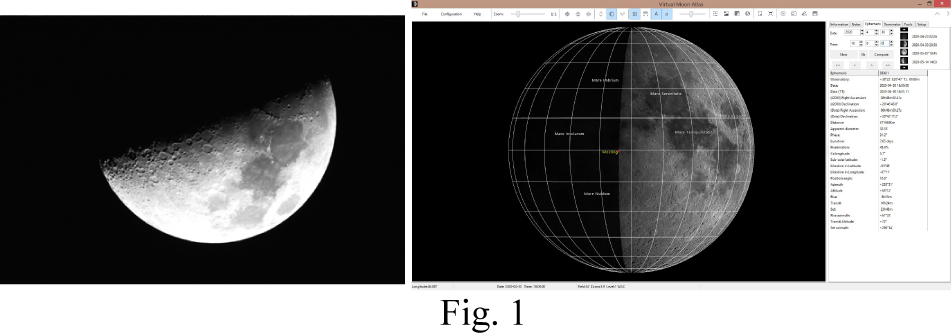

Fig. 1: (*Left*) The Moon photographed on 30 April 2020 (PHOTO: F. Pinto); (*Right*) The Virtual Moon Atlas main screen.

## 1. Introduction

*Note*: 

After executing any item, check off the box by typing the word "checked" (without double quotes) after the doubled quotes. The language to check off a box is here at an invisible comments line (open the cell to view it):

<!-- + COMMENT: After executing any item, check off the box by typing the word checked after the doubled quotes + --> 

Example <input type="checkbox" > <input type="checkbox" checked>

---

Your **goals** are:

**Goal 1.** To connect an actual image of the Moon to the information avalable from an atlas by the determination of the *plate constants* (Fig. 1). 

**Goal 2.** To obtain the scale of the image (km/pixel).

**Goal 3.** To estimate the libration in longitude and latitude. 

**Goal 4.** To estimate the errors in your results by considering the residuals of the best-fit procedures. 

**NEEDED TOOLS**:


<input type="checkbox" >  **1.**  **Download the data files provided from my OSF area** (https://osf.io/tehp2/) at 

Urla Iskelesi Station<br />
Urla Iskelesi Station: Selenography<br />
Urla Iskelesi Station Selenography: Meade ETX-90<br />
Files<br />
2023-04-13<br />
ScienceFrames<br />

<input type="checkbox"> At this point, reproduce the entire folder/subfolder structure you find at my cloud folder for the day of 2023-04-13. 

<input type="checkbox"> Store the FITS image found at /ScienceFrames into folder:

C:/AE-451/DataFiles/2023-04-13/ScienceFrames

This is the image to be reduced (the plate to be solved), provided in FITS format. 

<input type="checkbox"> Also, download the test data file 

<!-- + fabrizio-pinto-project-1-9405-20220409.txt  + --> 
fabrizio-pinto-everybody-5980-04302020-2
to your folder 

C:/AE-451/DataFiles/2023-04-13/Measurements . 

Please note that this file does *not* refer to the image you downloaded and it is an unrelated example only. 

<input type="checkbox"> **2.** ** Download/update AstroImageJ.** 

Download/update to the latest version by following the link available at the FOSS Freeplane mindmap. 

<input type="checkbox"> **3.** **Download/update the Virtual Moon Atlas (VMA).**

The VMA can also simulate the illumination conditions at the epoch the image was acquired. 

Download/update to the latest version of the VMA by following the link available at the FOSS Freeplane mindmap.

<input type="checkbox">  **4.** Be ready to launch **Notepad or Notepad++**. <br />
$~~~$ This application will be used to record your observations and the feature coordinates in pure ASCII characters. Feel free to use **Notepad++** if you find it  <br /> $~~~$  helpful.    

## 2. Selenographic coordinates

As also on Earth, the position of any point ${\bf P}$ on the Moon is identified by means of its selenographic longitude $\lambda$ and latitude $\beta$. The definitions needed to assign such coordinates are described in the References and are discussed in class. Here, for simplicity, we shall neglect parallctic effects due to the finite distance of the Moon from the Earth and we shall assume the image as representing the Moon from an infinite distance. By means of AstroImageJ, the pixel coordinates of every point ($x$, $y$) on the CCD sensor must be connected to the actual selenographic coordinates ($\lambda$, $\beta$). 

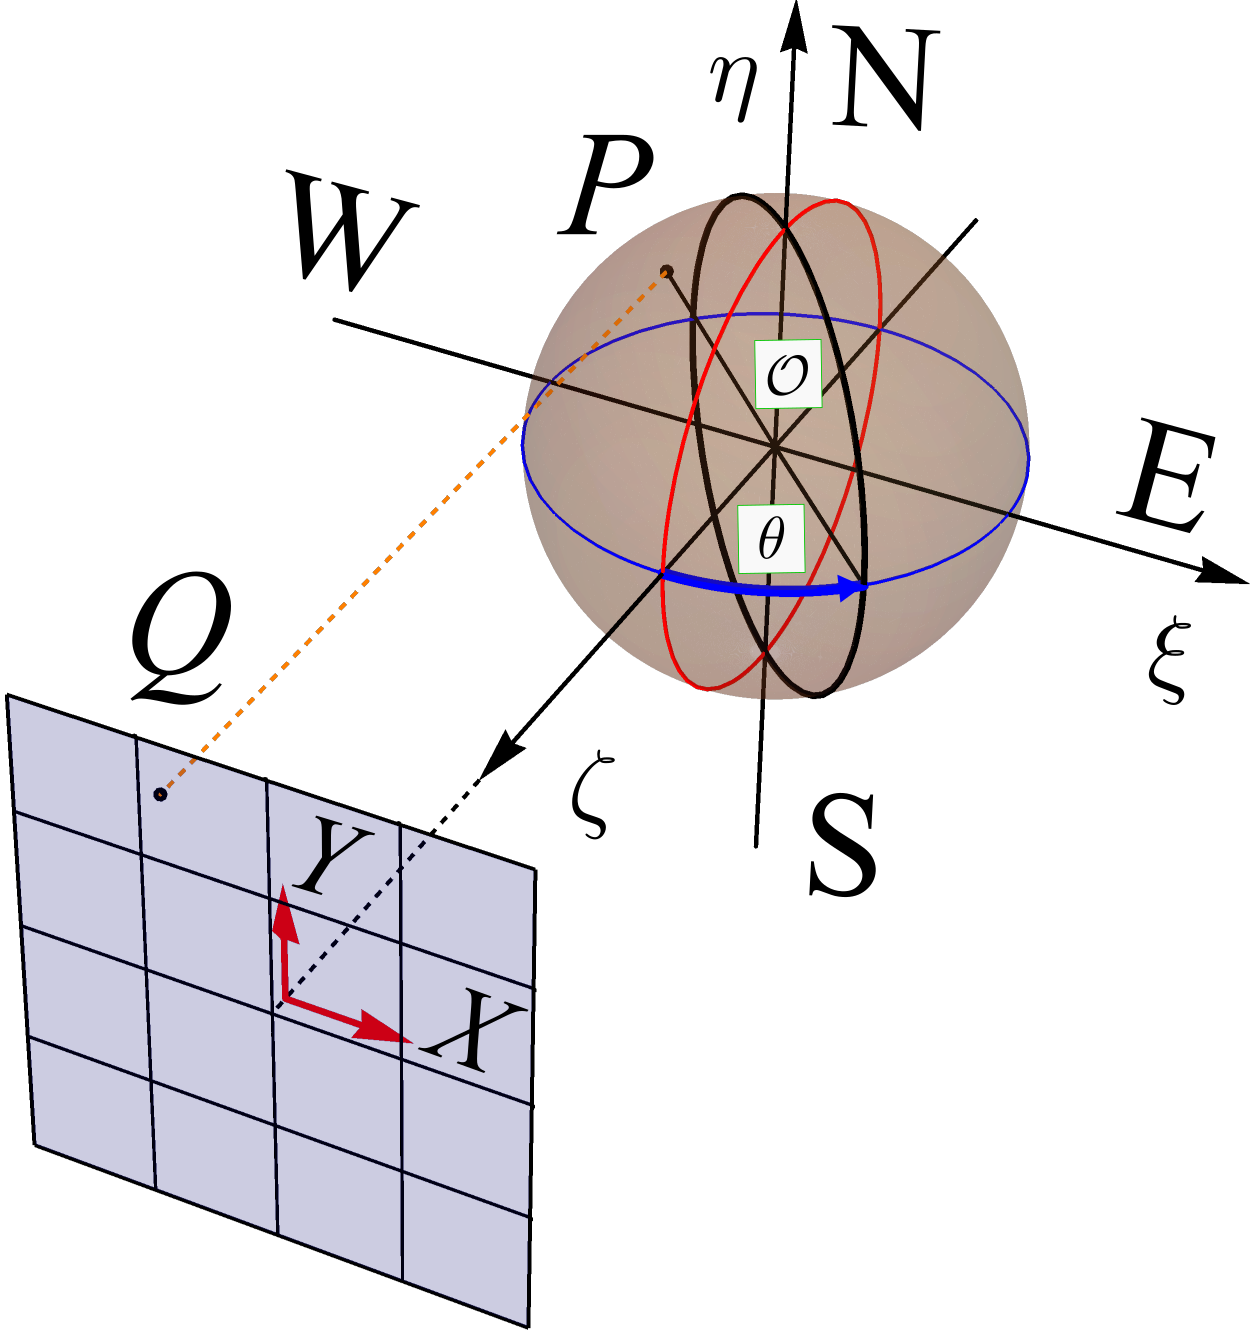

From the definitions above, the Cartesian components of point ${\bf P}$ in the ($\hat{\xi}$, $\hat{\eta}$, $\hat{\zeta}$) reference frame are: 

\begin{align}
& \xi_P = \cos\beta_P\sin\lambda_P\, , \tag{1}\\
& \eta_P = \sin\beta_P\, ,\\
& \zeta_P = \cos\beta_P\cos\lambda_P\, ,
\end{align}

where, if the Moon is assumed to be spherical, $\xi^2_P + \eta^2_P+\zeta^2_P=1$. Therefore, the relationships, assumed linear, connecting the plate coordinates ($x_P$, $y_P$) to the coordinates ($\xi_P$, $\eta_P$, $\zeta_P$) are:

\begin{align}
& x_P = A \xi_P + B \eta_P + C \zeta_P + D\, , \tag{2}\\
& y_P = E \xi_P + F \eta_P + G \zeta_P + H\, ,
\end{align}

where $A\dots D, E\dots H$ are the plate constants. 

In principle, measurements of the ($x_P$, $y_P$) coordinates of $4$ features would be sufficient to determine all plate constants. However, given various sources of error, it is important to carry out many measurements and to determine such quantites by a least-squares best fit (see below).   

## 3. Plate measurements

<input type="checkbox">  **5. Launch the VMA and prepare it for your measurements.** 

<input type="checkbox">  Under `Configuration` (top left), enter the following coordinates and choices:

Observatory<br >

Choose: Topocentric

Latitude: 38.3573°N &emsp; Longitude: 26.7795°E <br >
Country: GMT <br>
Time Zone: Etc/GMT

Under `Display`,  make choices that clearly allow you to see the features you are measuring. You may want to decrease the label density, for instance. 

Under `Texture`, start with Phase without relief and make more sohisticated choices if your graphics card can handle the VMA at very high resolution, AstroImageJ, and Jupyter running at the same time. Select LRO WAC Mosaic (bottom choice) but do feel free to explore other choices. When you move around any graphics objects, *be patient*. The VMA is showing you a mathematically calculated object and not just a photograph. When you move around or zoom in/out, your computer must do complex calculations. 

Under `Overlay`, Start with No overlay (uncheck Show overlay). However, do experiment with other choices. 

Under `Images`, Check for optional features. Be aware there is a wealth of imagery you can download as needed to complete lunar projects. 

Close Configuration (choose OK)

<input type="checkbox">  Go to `Lighting`. 

Start with Penumbra and Specular in the $40$-$50$% range.

Set both Diffuse and Smoothness and $100$%. 

Check Anti-alias.  

<input type="checkbox">  Go to `Information`. 

<input type="checkbox">  **6. Carry out a data file functionality check.**

Without closing any other applications, open Notepad and choose the test data file stored in folder /Measurements . 

<input type="checkbox">  Use the small data file indicated below, downloaded from my website under Measurements. Check that the syntax below produces results and that Wolfram Mathematica writes the output file. Check that the name and file location correctly match your case. 

Notice that at the end of the cell, I have erased a ";" which would have silenced the output. That will be useful later, when you have many features in your own file. 

In [57]:
PlateMeasurements = Import["D:/AE-451/Project1/DataFiles/2023-04-13/Measurements/kaoutar-ammara-spring-2026-ae-451-project-1.dat", "Table"];

(* --- Reference dataset (professor's file) – do NOT overwrite ---
   PlateMeasurements = Import["D:/AE-451/fabrizio-pinto-everybody-5980-04302020-21.txt", "Table"]; *)

Print["Features loaded: ", Length[PlateMeasurements]];
Print["First feature  : ", PlateMeasurements[[1]]];

Features loaded: 126
First feature  : {Copernicus, 1094.78, 1519.61, -20.1, 9.621}


## PASS 1 : Raw Pixel Coordinates
All cells below process the **raw** (uncorrected) measurement file.

You can isolate different variables from this entry by using the following syntax:

In [69]:
PlateMeasurements[[1]]
PlateMeasurements[[1, 1]]
PlateMeasurements[[1, 2]]
PlateMeasurements[[1, 3]]
PlateMeasurements[[1, 4]]
PlateMeasurements[[1, 5]]

{Copernicus, 1094.78, 1519.61, -20.1, 9.621}
Copernicus
1094.78
1519.61
-20.1
9.621

As the number of features you are measuring increases, you can read them individually by just changing the value of the first index, K:

PlateMeasurements[[K, 3]]

In this sample file, you find only one feature. As you proceed with your work, monitor how your estimates and residuals behave as you increase the number of features considered. You must add 40-100 measurements carried out by you. Also **remember** that that two values ($1321$, $2710$) do **not** apply to you. Measure Alphonsus again to obtain the pixel coordinates that are correct for you. 

<input type="checkbox">  If this test succeeded, change the name of the test data file to the following:

<span style='color:red'>  (this is what I would do if I were a student in AE-451 - change this to your name and to the image date! )</span>

**fabrizio-pinto-ae-451-project-1-2022-04-09-9405.txt**

<input type="checkbox">  **7. Open AstroImageJ and record the date/time of the observation from the FITS header.**

<input type="checkbox">  Open the FITS file in /ScienceFrames .

<input type="checkbox">  Go to Tools, and use the Rotate Image options to place the North pole of the Moon up as closely as possible. Make sure that the *Mare Imrbrium* is at left/up and the lit part of the Moon is on the left with the terminator running vertically along the image.  

Notice that two cursors, `Minimum` and `Maximum`, which you can move to optimize brightness and contrast during your measurements.  

<input type="checkbox">  At top right, notice the FITS HEADER. Observe and copy below (right in this cell) the value of the daye/time variable (remember this is GMT): 

DATE-OBS= ’2022-04-xyT12:34:56

<input type="checkbox"> **8.  Set up the correct date/time in the VMA.** 

At far right, go to `Ephemeris`, and enter the **same** Date and UTC Time shown by AstroImageJ in the FITS header (DATE-OBS). Always remember to click on `Compute`. 

<input type="checkbox"> **9A.  MEASURE THE PLATE.** 

As we discussed in class several times, choose $40$-$100$ features arranged **throughout the lunar disk**, carefully measure their pixel coordinates (round up the pixel coordinate to the nearest integer), and annotate the latitude and longitude in the same line in the text data file. 

<span style='color:red'>  **ATTENTION: If the feature has a composite name, such *Alphonsus B*, you MUST write it as AlphonsusB or the Jupyter Notebook will crash.** </span>



After you have measured at least $20$ features, and every $20$ features thereafter, carry out a check by reading out the data file with the same cell above (**PlateMeasurements =** ...) Remember to change the name of the file in that cell to the file name containing **your** name.  

In [107]:
(* Change the first "1" to other values*)

PlateMeasurements[[99]]
PlateMeasurements[[99, 1]]
PlateMeasurements[[99, 2]]
PlateMeasurements[[99, 3]]
PlateMeasurements[[99, 4]]
PlateMeasurements[[99, 5]]

{Wolf, 1189.6, 712.201, -16.633, -22.706}
Wolf
1189.6
712.201
-16.633
-22.706

The size of the sample is obtained. This number, $N_f$, must match the number of features you used. If it does not, you may have added blank lines or spaces at the bottom. **Delete any additional blanks**.   

In [118]:
FeatureMax = Length[PlateMeasurements]

126

<input type="checkbox">  **9B.  SAVE THE VMA SCREEN.**

In the VMA, go to `File`, choose Save As, choose JPG and save the screen to:

`D:\AE-451\Project1\DataFiles\2023-04-13\kaoutar-ammara-spring-2026-ae-451-project-1-2023-04-13-VMA.jpg`

This file must be included in your submission package.


## 4. DATA FILE MANIPULATION AND FEATURE DISTRIBUTION

<input type="checkbox">   **10. Execute all cells in this Section 4 to prepare your data for analysis.** 

Now that all data have been read, the Cartesian coordinates ($\xi_P$, $\eta_P$, $\zeta_P$) of every feature in the selenographic Cartesian frame are obtained from Eqs. (1). Let us use the information in the data file to assemble a list of all measured ($X$, $Y$) coordinates of the given features. We first create (Riffle) two flattened lists of the two coordinates and then we partition them into pairs so as to obtain one list ($X_i$, $Y_i$) coordinates for the $i$-th feature:  

In [135]:


PixelCoordinatesX = Part[PlateMeasurements[[1 ;; FeatureMax , 2]]];
PixelCoordinatesY = Part[PlateMeasurements[[1 ;; FeatureMax , 3]]];

Riffle[PixelCoordinatesX , PixelCoordinatesY];
PixelCoordinates = Partition[Riffle[PixelCoordinatesX , PixelCoordinatesY], 2];

The same procedure can be followed to create a list of all coordinates of features identified from a lunar atlas and whose coordinates, longitude $\lambda$ and latitude $\beta$, both in degrees, are known: 

In [144]:

FeatureCoordinatesLong = Part[PlateMeasurements[[1 ;; FeatureMax , 4]]];
FeatureCoordinatesLat =  Part[PlateMeasurements[[1 ;; FeatureMax , 5]]]; 

FeatureCoordinatesLongLat = Partition[Riffle[FeatureCoordinatesLong , FeatureCoordinatesLat ], 2];

A distribution of these coordinates is provided by a ($\lambda$, $\beta$)-diagram. Notice that West longitude corresponds to $\lambda> 0^\circ$.

Legended[-Graphics-, Placed[PointLegend[{Directive[PointSize[0.00916667], 
 
>       AbsoluteThickness[2], RGBColor[0, 0, 1]], 
 
>      Directive[PointSize[0.00916667], AbsoluteThickness[2], RGBColor[0, 1, 0]], 
 
>      Directive[PointSize[0.00916667], AbsoluteThickness[2], RGBColor[1, 0.5, 0]], 
 
>      Directive[PointSize[0.00916667], AbsoluteThickness[2], RGBColor[1, 0, 0]]}, 
 
>     {β < −30°, −30° ≤ β < 0°, 0° ≤ β < 30°, β ≥ 30°}, 
 
>     LegendMarkers -> 
 
>      {{False, Automatic}, {False, Automatic}, {False, Automatic}, {False, Automatic}}, 
 
>     Joined -> {False, False, False, False}, LabelStyle -> {}, LegendLayout -> Column], 
 
>    After, Identity]]
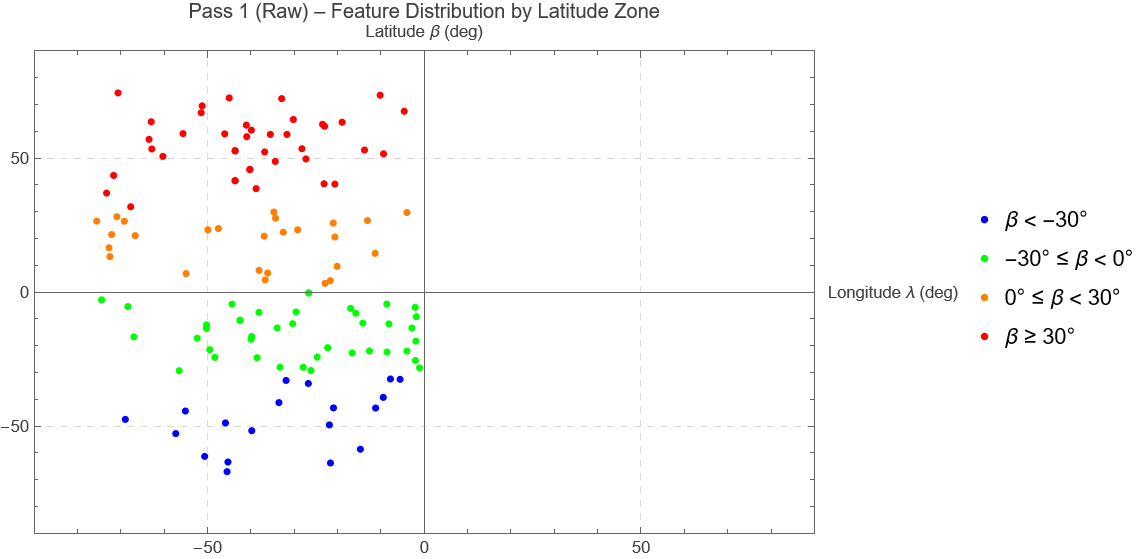

In [152]:
(* Enhanced (λ,β)-distribution plot PASS 1 (Raw) *)
southFeatures = Select[FeatureCoordinatesLongLat, #[[2]] < -30 &];
midSFeatures  = Select[FeatureCoordinatesLongLat, -30 <= #[[2]] < 0 &];
midNFeatures  = Select[FeatureCoordinatesLongLat,   0 <= #[[2]] < 30 &];
northFeatures = Select[FeatureCoordinatesLongLat, #[[2]] >= 30 &];

LambdaBetaPlotRaw = ListPlot[
  {southFeatures, midSFeatures, midNFeatures, northFeatures},
  PlotRange    -> {{-90, 90}, {-90, 90}},
  PlotStyle    -> {Blue, Green, Orange, Red},
  PlotLegends  -> {"β < −30°", "−30° ≤ β < 0°", "0° ≤ β < 30°", "β ≥ 30°"},
  AxesLabel    -> {"Longitude λ (deg)", "Latitude β (deg)"},
  PlotLabel    -> "Pass 1 (Raw) – Feature Distribution by Latitude Zone",
  GridLines    -> Automatic,
  GridLinesStyle -> Directive[LightGray, Dashed],
  Frame -> True, ImageSize -> Large
];
LambdaBetaPlotRaw

In [159]:
(* Export Pass 1 *)
Export["D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-raw-lambda-beta-dist.pdf", LambdaBetaPlotRaw]
Export["D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-raw-lambda-beta-dist.png", LambdaBetaPlotRaw]

D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-raw-lambda-beta-d\
 
>   ist.pdf
D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-raw-lambda-beta-d\
 
>   ist.png

The map above shows the distribution of features you chose. You can query the longitude and latitude of individual features to check that the list was properly manipulated and you obtain the correct values for every feature you used: 

In [166]:

FeatureCoordinatesLongLat;
FeatureCoordinatesLongLat[[1, 1]];
FeatureCoordinatesLongLat[[1, 2]];

Let us now assemble a list of the three dimensional coordinates in the local lunar Cartesian system, ($\xi_i$, $\eta_i$,  $\zeta_i$) for every such feature, by using the standard equations (Kopal1974, Eqs. (3.12)):

$$
\xi_i = \cos\beta_i \sin\lambda_i\, ,
$$

$$
\eta_i = \sin\beta_i \, ,
$$ 

$$
\zeta_i = \cos\beta_i \cos\lambda_i\, ,
$$ 
where $\xi^2_i + \eta^2_i + \zeta^2_i = 1$.  

In [174]:
(* Erase the ";" to understand what this process accomplishes. Replace the ";" when you are done to reduce output.*)

SelenographicCartesian3D = 
Table[{(Cos[FeatureCoordinatesLongLat[[i, 2]] Degree] Sin[FeatureCoordinatesLongLat[[i, 1]] Degree]), (Sin[FeatureCoordinatesLongLat[[i, 2]] Degree]), (Cos[
       FeatureCoordinatesLongLat[[i, 2]] Degree] Cos[FeatureCoordinatesLongLat[[i, 1]] Degree])}, {i, 1, FeatureMax}];

The expression below is the standard Least Squares solution for the Multivariate Regression model in matrix language. Notice that this is done twice, once using the $x$- coordinates and then again with $y$-pixel coordinates. For an introductory but thorough description of this strategy, with examples, you are required to read and to reference: https://online.stat.psu.edu/stat462/node/132/ . The following cell yields $A$, $B$, $C$, and $D$.    

For instance, for the $1$st feature in the list:

In [184]:
SelenographicCartesian3D[[1]]

{-0.338826, 0.16713, 0.925886}

This list can be broken down into lists for each of the three components so as to produce a list of  ($\xi_i$, $\eta_i$) coordinates only. In the absence of librations and neglecting the finite distance of the Moon from the observer, this would represent the position of the measured features on the surface: 

In [189]:

SelenographicCartesianxi = Part[SelenographicCartesian3D[[1 ;; FeatureMax , 1]]];
SelenographicCartesianeta = Part[SelenographicCartesian3D[[1 ;; FeatureMax , 2]]];
SelenographicCartesianzeta = Part[SelenographicCartesian3D[[1 ;; FeatureMax , 3]]];

SelenographicCartesian2D = Partition[Riffle[SelenographicCartesianxi, SelenographicCartesianeta], 2];

A diagram shows this distribution:

-Graphics-
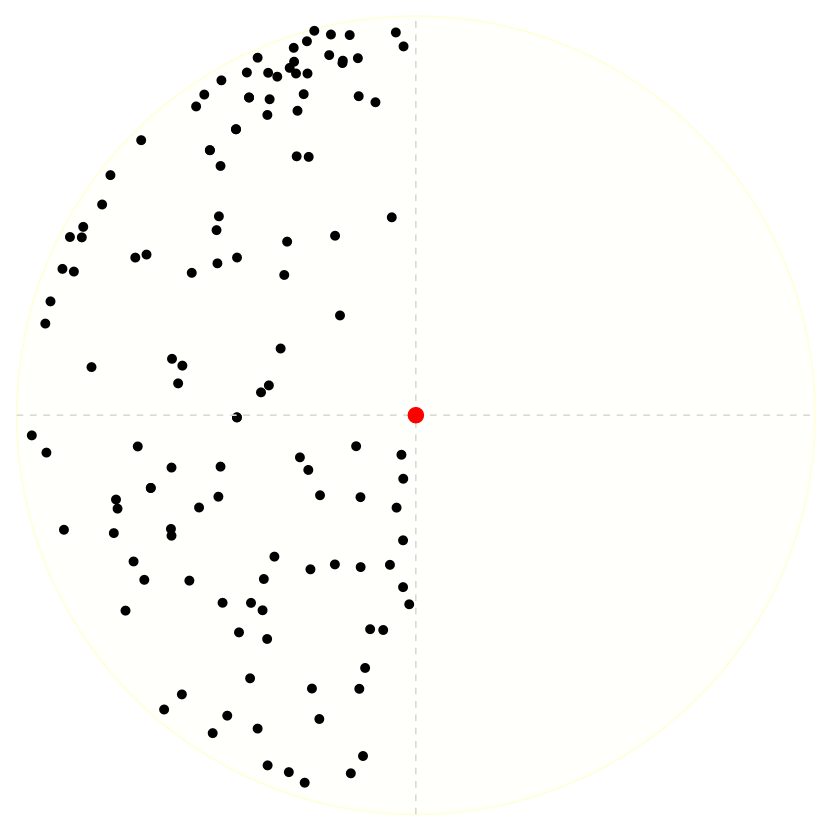

In [198]:
(* Enhanced 2-D selenographic distribution  PASS 1 (Raw) *)
SelenographicCartesian2DPLOT = ListPlot[
  SelenographicCartesian2D,
  PlotRange   -> {{-1.1, 1.1}, {-1.1, 1.1}},
  AspectRatio -> 1.0,
  PlotStyle   -> Directive[Black, PointSize[0.012]],
  AxesLabel   -> {"ξ", "η"},
  PlotLabel   -> "Pass 1 (Raw) – Measured Features on Lunar Disk (ξ, η)",
  GridLines   -> Automatic,
  Frame -> True];
LunarDisk    = Graphics[{Opacity[0.08, LightYellow], Disk[{0,0},1], Opacity[1], Circle[{0,0},1]}];
LunarEquator = Graphics[{Dashed, LightGray, Line[{{-1,0},{1,0}}]}];
LunarMerid   = Graphics[{Dashed, LightGray, Line[{{0,-1},{0,1}}]}];
LunarCenter  = Graphics[{Red, PointSize[0.02], Point[{0,0}]}];
DiskPlotRaw = Show[LunarDisk, SelenographicCartesian2DPLOT,
                   LunarEquator, LunarMerid, LunarCenter, ImageSize -> 500];
DiskPlotRaw

In [206]:
(* Export Pass 1: Lunar disk*)
Export["D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-raw-xi-eta-disk.pdf", DiskPlotRaw]
Export["D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-raw-xi-eta-disk.png", DiskPlotRaw, ImageResolution -> 300]

D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-raw-xi-eta-disk.p\
 
>   df
D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-raw-xi-eta-disk.p\
 
>   ng

## 5. PLATE CALIBRATION

Let us now determine the Plate Constants. In order to prepare data as required by Mathematica (see for instance https://mathematica.stackexchange.com/questions/126283/performing - multiple - linear - regression - in - mathematica), we use Riffle to create alternate records of the 4 quantities  ($\xi_i$, $\eta_i$,  $\zeta_i$) and $X_i$, and then we flatten such list and partition it into separate ($\xi_i$, $\eta_i$,  $\zeta_i$, $X_i$) records, and identically for  ($\xi_i$, $\eta_i$,  $\zeta_i$, $Y_i$). In this way, we prepare the data for a linear model of the type required for a determination of the Plate Constants (Saunder1900, p. 184):

$$
x = A\xi + B\eta + C\zeta + D\, ,
$$

$$
y = E\xi + F\eta + G\zeta + H\, ,
$$

In [213]:

PlateConstantsDataX = Partition[Flatten[Riffle[SelenographicCartesian3D, PixelCoordinatesX]], 4];
PlateConstantsDataY = Partition[Flatten[Riffle[SelenographicCartesian3D, PixelCoordinatesY]], 4];

<input type="checkbox">  **11. Calculate the Plate Constants, ($A$, $B$, $C$,$D$, $E$, $F$, $G$, $H$) by a linear best fit:** 

<span style='color:red'>  **ATTENTION: You cannot carry out this operation if you have fewer than 8 measurements and, realistically, you need many more.**</span>

In [220]:
BestFitX = FindFit[PlateConstantsDataX, Dpc + Apc xi + Bpc eta + Cpc zeta, {Dpc, Apc, Bpc, Cpc}, {xi, eta, zeta}]
BestFitY =  FindFit[PlateConstantsDataY, Hpc + Epc xi + Fpc eta + Gpc zeta, {Hpc, Epc, Fpc, Gpc}, {xi, eta, zeta}]

{Dpc -> 1516.14, Apc -> 1468.58, Bpc -> 29.2728, Cpc -> 75.6608}
{Hpc -> 1433.34, Epc -> -34.9102, Fpc -> 1462.12, Gpc -> -182.671}

Additional information is available with the same syntax and data format by executing a Non-linear instruction, which in this case again corresponds to a linear fit. The residuals allow you to assess the goodness of fit. 

FittedModel[<|Type -> Nonlinear, Model -> 
 
>     <|FittedParameterRules -> 
 
>       {Dpc -> 1516.14, Apc -> 1468.58, Bpc -> 29.2728, Cpc -> 75.6608}, 
 
>      IndependentVariables -> {xi, eta, zeta}, 
 
>      FitExpression -> Dpc + Bpc eta + Apc xi + Cpc zeta, ParameterConstraints -> True|>
 
>     , KeyNames -> Automatic, Weights -> <|ExampleWeights -> 1|>, 
 
>    InputData -> 
 
>     {{-0.338826, 0.16713, 0.925886, 1094.78}, 
 
>      {-0.190009, 0.249941, 0.949435, 1315.48}, 
 
>      {-0.36818, 0.0746829, 0.92675, 1044.72}, 
 
>      {-0.387956, 0.057233, 0.919899, 1018.34}, 
 
>      {-0.448267, -0.0054454, 0.893883, 924.777}, 
 
>      {-0.0501604, 0.958775, 0.279704, 1499.52}, 
 
>      {-0.165771, 0.952247, 0.25641, 1328.99}, 
 
>      {-0.212733, 0.953643, 0.212859, 1251.09}, {-0.272852, 0.93677, 0.21912, 1166.11}, 
 
>      {-0.254385, 0.96296, 0.0894183, 1183.31}, 
 
>      {-0.101225, 0.783899, 0.612581, 1447.37}, {-0.14531, 0.894303, 0.423211, 1369.6}, 
 
>      {-0.18391, 0.882127, 0.433623, 1312.67}, {-0.182932, 0.88808, 0.421722, 1312.43}, 
 
>      {-0.0308079, 0.923859, 0.38149, 1533.28}, 
 
>      {-0.143237, 0.799087, 0.583903, 1377.99}, 
 
>      {-0.305992, 0.92028, 0.243833, 1119.89}, 
 
>      {-0.396378, 0.895564, 0.202113, 989.275}, 
 
>      {-0.305024, 0.885507, 0.350482, 1110.38}, 
 
>      {-0.369993, 0.857751, 0.356887, 1030.93}, 
 
>      {-0.347171, 0.848067, 0.400319, 1076.88}, 
 
>      {-0.300239, 0.855969, 0.420919, 1139.5}, 
 
>      {-0.271429, 0.855969, 0.440048, 1180.61}, 
 
>      {-0.280994, 0.804241, 0.523678, 1171.53}, 
 
>      {-0.217086, 0.902081, 0.372992, 1155.19}, 
 
>      {-0.296498, 0.762634, 0.574872, 1145.82}, 
 
>      {-0.371966, 0.752196, 0.543914, 1035.61}, 
 
>      {-0.366282, 0.791458, 0.489317, 1056.29}, 
 
>      {-0.316046, 0.870003, 0.37843, 977.839}, 
 
>      {-0.417847, 0.795812, 0.438277, 967.978}, 
 
>      {-0.450544, 0.716314, 0.532826, 918.359}, 
 
>      {-0.516032, 0.663887, 0.541262, 825.628}, 
 
>      {-0.489298, 0.62433, 0.608934, 866.673}, 
 
>      {-0.298642, 0.648532, 0.700157, 1153.15}, 
 
>      {-0.268443, 0.647149, 0.713538, 1199.1}, 
 
>      {-0.423364, 0.858513, 0.289341, 949.282}, 
 
>      {-0.487121, 0.838832, 0.24305, 841.676}, 
 
>      {-0.530038, 0.803161, 0.272017, 780.975}, 
 
>      {-0.550468, 0.773475, 0.314198, 763.996}, 
 
>      {-0.688034, 0.688861, 0.228212, 550.896}, 
 
>      {-0.765151, 0.601355, 0.230037, 431.365}, 
 
>      {-0.785965, 0.527757, 0.322075, 405.781}, 
 
>      {-0.833176, 0.471782, 0.288513, 337.124}, 
 
>      {-0.836855, 0.445464, 0.318176, 329.523}, 
 
>      {-0.866533, 0.446385, 0.223294, 286.198}, 
 
>      {-0.885362, 0.36655, 0.285964, 254.918}, {-0.856707, 0.35985, 0.369541, 300.276}, 
 
>      {-0.674758, 0.402427, 0.618671, 579.5}, {-0.702782, 0.394808, 0.591797, 553.964}, 
 
>      {-0.915206, 0.285153, 0.284757, 207.591}, 
 
>      {-0.928244, 0.229574, 0.292674, 182.999}, 
 
>      {-0.610848, 0.141264, 0.779044, 681.534}, 
 
>      {-0.584874, 0.124173, 0.801563, 719.666}, 
 
>      {-0.595487, 0.0796944, 0.799402, 700.193}, 
 
>      {-0.812518, 0.120483, 0.570349, 308.533}, 
 
>      {-0.925477, -0.0936739, 0.367039, 186.101}, 
 
>      {-0.962009, -0.0505929, 0.26829, 126.411}, 
 
>      {-0.696682, -0.0783025, 0.713094, 543.461}, 
 
>      {-0.66406, -0.182253, 0.725126, 592.38}, 
 
>      {-0.747314, -0.233988, 0.62191, 457.725}, 
 
>      {-0.751132, -0.21124, 0.625442, 452.161}, 
 
>      {-0.881571, -0.286976, 0.374804, 245.171}, 
 
>      {-0.756611, -0.295341, 0.583364, 439.13}, 
 
>      {-0.61218, -0.301788, 0.730862, 660.481}, 
 
>      {-0.613591, -0.284852, 0.736455, 654.465}, 
 
>      {-0.707181, -0.366388, 0.604694, 513.214}, 
 
>      {-0.680199, -0.412373, 0.606035, 547.713}, 
 
>      {-0.727405, -0.48955, 0.480857, 464.249}, 
 
>      {-0.567396, -0.414344, 0.711605, 722.43}, 
 
>      {-0.484207, -0.469903, 0.738061, 841.505}, 
 
>      {-0.412993, -0.470
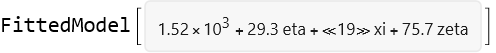
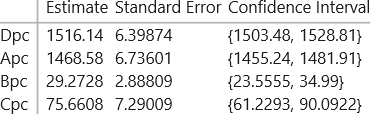

In [226]:

BestFitXnlm = NonlinearModelFit[PlateConstantsDataX, Dpc + (Apc ) xi + (Bpc ) eta + (Cpc) zeta, {Dpc, Apc, Bpc, Cpc}, {xi, eta, zeta}]

BestFitXnlm["BestFitParameters"];
BestFitXnlm[{"BestFit", "FitResiduals", "ParameterTable"}];
BestFitXnlm[{"FitResiduals"}];
BestFitXnlm[{"ParameterConfidenceIntervals"}];
BestFitXnlm["ParameterConfidenceIntervalTable"]

FittedModel[<|Type -> Nonlinear, Model -> 
 
>     <|FittedParameterRules -> 
 
>       {Hpc -> 1433.34, Epc -> -34.9102, Fpc -> 1462.12, Gpc -> -182.671}, 
 
>      IndependentVariables -> {xi, eta, zeta}, 
 
>      FitExpression -> eta Fpc + Hpc + Epc xi + Gpc zeta, ParameterConstraints -> True|>
 
>     , KeyNames -> Automatic, Weights -> <|ExampleWeights -> 1|>, 
 
>    InputData -> 
 
>     {{-0.338826, 0.16713, 0.925886, 1519.61}, 
 
>      {-0.190009, 0.249941, 0.949435, 1635.06}, 
 
>      {-0.36818, 0.0746829, 0.92675, 1386.38}, 
 
>      {-0.387956, 0.057233, 0.919899, 1361.51}, 
 
>      {-0.448267, -0.0054454, 0.893883, 1276.64}, 
 
>      {-0.0501604, 0.958775, 0.279704, 2797.28}, 
 
>      {-0.165771, 0.952247, 0.25641, 2793.09}, 
 
>      {-0.212733, 0.953643, 0.212859, 2809.28}, {-0.272852, 0.93677, 0.21912, 2785.}, 
 
>      {-0.254385, 0.96296, 0.0894183, 2843.68}, 
 
>      {-0.101225, 0.783899, 0.612581, 2478.46}, 
 
>      {-0.14531, 0.894303, 0.423211, 2680.17}, {-0.18391, 0.882127, 0.433623, 2659.45}, 
 
>      {-0.182932, 0.88808, 0.421722, 2666.41}, 
 
>      {-0.0308079, 0.923859, 0.38149, 2726.14}, 
 
>      {-0.143237, 0.799087, 0.583903, 2506.57}, 
 
>      {-0.305992, 0.92028, 0.243833, 2755.97}, 
 
>      {-0.396378, 0.895564, 0.202113, 2731.73}, 
 
>      {-0.305024, 0.885507, 0.350482, 2672.6}, 
 
>      {-0.369993, 0.857751, 0.356887, 2644.33}, 
 
>      {-0.347171, 0.848067, 0.400319, 2626.6}, 
 
>      {-0.300239, 0.855969, 0.420919, 2625.84}, 
 
>      {-0.271429, 0.855969, 0.440048, 2619.4}, 
 
>      {-0.280994, 0.804241, 0.523678, 2527.64}, 
 
>      {-0.217086, 0.902081, 0.372992, 2548.37}, 
 
>      {-0.296498, 0.762634, 0.574872, 2456.59}, 
 
>      {-0.371966, 0.752196, 0.543914, 2449.47}, 
 
>      {-0.366282, 0.791458, 0.489317, 2518.33}, 
 
>      {-0.316046, 0.870003, 0.37843, 2490.51}, 
 
>      {-0.417847, 0.795812, 0.438277, 2536.88}, 
 
>      {-0.450544, 0.716314, 0.532826, 2402.8}, 
 
>      {-0.516032, 0.663887, 0.541262, 2328.27}, 
 
>      {-0.489298, 0.62433, 0.608934, 2256.06}, 
 
>      {-0.298642, 0.648532, 0.700157, 2266.81}, 
 
>      {-0.268443, 0.647149, 0.713538, 2265.13}, 
 
>      {-0.423364, 0.858513, 0.289341, 2656.98}, 
 
>      {-0.487121, 0.838832, 0.24305, 2639.51}, 
 
>      {-0.530038, 0.803161, 0.272017, 2580.65}, 
 
>      {-0.550468, 0.773475, 0.314198, 2531.51}, 
 
>      {-0.688034, 0.688861, 0.228212, 2427.64}, 
 
>      {-0.765151, 0.601355, 0.230037, 2297.33}, 
 
>      {-0.785965, 0.527757, 0.322075, 2177.48}, 
 
>      {-0.833176, 0.471782, 0.288513, 2104.47}, 
 
>      {-0.836855, 0.445464, 0.318176, 2063.43}, 
 
>      {-0.866533, 0.446385, 0.223294, 2092.31}, 
 
>      {-0.885362, 0.36655, 0.285964, 1942.39}, {-0.856707, 0.35985, 0.369541, 1922.78}, 
 
>      {-0.674758, 0.402427, 0.618671, 1930.87}, 
 
>      {-0.702782, 0.394808, 0.591797, 1917.72}, 
 
>      {-0.915206, 0.285153, 0.284757, 1833.19}, 
 
>      {-0.928244, 0.229574, 0.292674, 1746.18}, 
 
>      {-0.610848, 0.141264, 0.779044, 1515.58}, 
 
>      {-0.584874, 0.124173, 0.801563, 1486.58}, 
 
>      {-0.595487, 0.0796944, 0.799402, 1420.62}, 
 
>      {-0.812518, 0.120483, 0.570349, 1555.51}, 
 
>      {-0.925477, -0.0936739, 0.367039, 1248.92}, 
 
>      {-0.962009, -0.0505929, 0.26829, 1337.95}, 
 
>      {-0.696682, -0.0783025, 0.713094, 1206.11}, 
 
>      {-0.66406, -0.182253, 0.725126, 1045.66}, 
 
>      {-0.747314, -0.233988, 0.62191, 995.585}, 
 
>      {-0.751132, -0.21124, 0.625442, 1031.2}, 
 
>      {-0.881571, -0.286976, 0.374804, 971.103}, 
 
>      {-0.756611, -0.295341, 0.583364, 916.676}, 
 
>      {-0.61218, -0.301788, 0.730862, 871.059}, 
 
>      {-0.613591, -0.284852, 0.736455, 923.595}, 
 
>      {-0.707181, -0.366388, 0.604694, 804.704}, 
 
>      {-0.680199, -0.412373, 0.606035, 741.272}, 
 
>      {-0.727405, -0.48955, 0.480857, 645.566}, 
 
>      {-0.567396, -0.414344, 0.711605, 713.45}, 
 
>      {-0.484207, -0.469903, 0.738061, 622.197}, 
 
>  
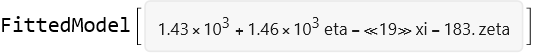

In [233]:
BestFitYnlm =  NonlinearModelFit[PlateConstantsDataY, Hpc + Epc xi + Fpc eta + Gpc zeta, {Hpc, Epc, Fpc, Gpc}, {xi, eta, zeta}]

BestFitYnlm["BestFitParameters"]
BestFitYnlm[{"BestFit", "FitResiduals", "ParameterTable"}];
BestFitYnlm[{"FitResiduals"}];
BestFitYnlm[{"ParameterConfidenceIntervals"}];
BestFitYnlm["ParameterConfidenceIntervalTable"];

###  Geometrical information available from the Plate Constants.

The plate constants have important geometric interpretations and yield additional information. For instance, the ($X_C$, $Y_C$) coordinates of the <span style='color:blue'>  **center of the Moon in the plate**</span>, in pixels, are the plate constants $D$ and $H$.

<input type="checkbox">  **12. Go to AstroImageJ and verify the two values below are reasonable.** 

In [247]:
(* This is the position of the point of lat=0, long=0*)

XOrigin = Normal[BestFitXnlm] /.{xi->0, eta ->0., zeta-> 1.0}
YOrigin = Normal[BestFitYnlm] /.{xi->0, eta ->0., zeta-> 1.0}

1591.8
1250.67

In [250]:
XCenter = BestFitX[[1, 2]] 
YCenter = BestFitY[[1, 2]]

1516.14
1433.34

<span style='color:blue'> **The radius of the Moon**</span>, in pixels, along the two axes on the image is the scale factor given by the sum of the squares of the remaining three plate constants in each set, that is: 

$$
R^2_X = A^2 + B^2 + C^2\, , 
$$

$$
R^2_Y = E^2 + F^2 + G^2\, . 
$$

<input type="checkbox">  **13. Go to AstroImageJ and verify the two values below are reasonable.**

In [260]:
RadiusX = Sqrt[(BestFitX[[2, 2]])^2 + (BestFitX[[3, 2]])^2 + (BestFitX[[4, 2]])^2]
RadiusY =  Sqrt[(BestFitY[[2, 2]])^2 + (BestFitY[[3, 2]])^2 + (BestFitY[[4, 2]])^2]

1470.82
1473.9

**ATTENTION.** Any difference between these two values must be attributed to both experimental error and possible field non-flatness. As one can see, these values coincide to within the order of magnitude of the fit residuals found. The average scale in km/pixel is, therefore, considering the average physical radius of the Moon ( https://nssdc.gsfc.nasa.gov/planetary/factsheet/moonfact.html ):

In [266]:
AvePixRadius = ((RadiusX + RadiusY)/2) 

AvePhysicalRadius = (1736.0 + 1738.1)/2 

AvePixelScale = (AvePhysicalRadius )/(AvePixRadius)

1472.36
1737.05
1.17977

The geometric interpretation of the plate constants also allow us to determine the <span style='color:blue'> **orientation of the polar axis**</span> of the Moon with respect to the vertical axis of the digital image (in degrees):

<input type="checkbox">  **14. Go to AstroImageJ and verify the value below is reasonable.**

In [277]:
BestFitX[[3, 2]]
BestFitY[[3, 2]]

ThetaRotObs = ArcTan[-BestFitX[[3, 2]]/BestFitY[[3, 2]]] (1/Degree)

29.2728
1462.12
-1.14695

## 6. Optical librations 

The <span style='color:blue'> **optical libration angles**</span> are revealed, therefore (Kopal1974, Eq. (3.15)), from a rotation in the opposite direction than the  polar axis above: 

In [284]:
AEUnRot = RotationMatrix[-ThetaRotObs Degree].{BestFitX[[2, 2]]/RadiusX, BestFitY[[2, 2]]/RadiusY}
AEUnRot[[1]]
ArcCos[AEUnRot[[1]]] (1/Degree)

{0.998752, -0.00369454}
0.998752
2.86309

<input type="checkbox">  **15. Calculate the observed libration angles.**


The variable $\lambda$ and $\beta$ below are <span style='color:blue'> **your estimates of the libration angles**</span>:

In [291]:
CGUnRot = RotationMatrix[-ThetaRotObs Degree].{BestFitX[[4, 2]]/RadiusX, BestFitY[[4, 2]]/RadiusY}

LambdaLibObs = -ArcSin[CGUnRot[[1]]] (1/Degree)
BetaLibObs = ArcSin[(-CGUnRot[[2]]/(Cos[-ArcSin[CGUnRot[[1]]]]))] (1/Degree)

{0.0539118, -0.122883}
-3.09042
7.06883

With the available data, we have the following <span style='color:blue'> **libration estimates obtained from observation**</span>, expressed in decimal degrees.  
*(The DMS values below are computed from the decimal output of the cells above.)*

Libration in Longitude: $\lambda_{\mathrm{lib, obs}} = -3.09042^\circ \approx -3^\circ\,05'$<br />
Libration in Latitude: $\beta_{\mathrm{lib, obs}} = +7.06883^\circ \approx +7^\circ\,04'$

*(Always re-read `N[LambdaLibObs]` and `N[BetaLibObs]` from the cell output above and recompute DMS as `IntegerPart[val]°` and `Round[60 Abs[FractionalPart[val]]]'`.)*

In [298]:
(* Preserve Pass 1 (Raw) results under unique variable names *)
LambdaLibObsResultRaw = LambdaLibObs;
BetaLibObsResultRaw   = BetaLibObs;
ThetaRotObsResultRaw  = ThetaRotObs;
RadiusXResultRaw      = RadiusX;
RadiusYResultRaw      = RadiusY;
AvePixScaleResultRaw  = AvePixelScale;
RMSXResultRaw       = Sqrt[Mean[BestFitXnlm["FitResiduals"]^2]];
RMSYResultRaw       = Sqrt[Mean[BestFitYnlm["FitResiduals"]^2]];
Print["Pass 1 (Raw) results saved as *ResultRaw"];

Pass 1 (Raw) results saved as *ResultRaw


## 7. Comparison with published data

<input type="checkbox">  **15. Record the libration angles from the VMA.**

This data must be compared to the <span style='color:blue'> **libration values given by the VMA**</span>  for the date/time given in the FITS header at the DATE-OBS entry. 

Below, reproduce the DATE-OBS line from th FITS header and the copy the libration angles given at `Ephemeris` for the exact time of this observation: 

The VMA provides:

$$
l_{0, {\mathrm{VMA}}} = -2^\circ\,\, 42' = -2.70^\circ \, ,
$$

$$
b_{0, {\mathrm{VMA}}} =7^\circ\,\, 30' = 7.50^\circ \, . 
$$

<input type="checkbox">  **16. Save the VMA ephemeris.**

In the VMA, go to `File`, choose `Save ephemeris to file`, change no options, and save the file to subfolder: 

C:/AE-451/DataFiles/2023-04-13/Measurements 

with file name:

<span style='color:red'>  (this is what I would do if I were a student in AE-451 - change this to your name! )</span>

<span style='color:blue'>  **fabrizio-pinto-ae-451-project-1-2022-04-09-ephem-VMA.txt**</span> 

In Project 2, you will learn how to produce an ephemeris file directly from the NASA/JPL database. 


<input type="checkbox">  **17. Record the absolute libration angle errors.**

Calculate and indicate below the <span style='color:blue'> **absolute errors of your libration estimates**</span>:

$$
\Delta \lambda = l_{0, {\mathrm{VMA}}} - \lambda_{\mathrm{lib, obs}}\, ,
$$

$$
\Delta \beta = b_{0, {\mathrm{VMA}}} - \beta_{\mathrm{lib, obs}} \, .
$$


## Project 1 Reporting activities

<span style='color:red'>  **Before the announced deadline**</span>, prepare your work for submission as
follows.

Click into the empty cell below, go to Edit above, choose `Insert Image` and include:

<input type="checkbox">  <span style='color:blue'> **3. YOUR VMA screenshot**</span>

Furthermore, when you upload this Jupyter Notebook to Blackboard, also
separately upload the following files: 

<input type="checkbox">  <span style='color:blue'> **4. YOUR DATA FILE listing all the features you used.**</span>

<input type="checkbox">  <span style='color:blue'> **5. The VMA Ephemeris FILE.**</span>

<input type="checkbox">  <span style='color:blue'> **6. YOUR SLIDE file, in pdf format**</span>

**Finally**, go to File above, choose `Download As` *Notebook (.ipynb)* 
and download this completed Notebook to

<input type="checkbox">  <span style='color:blue'> **1. AE-451/Projects/Project-1/fabrizio-pinto-spring-2023-ae-451-project-1.ipynb**</span> 

Repeat the same process saving the file to:

<input type="checkbox">  <span style='color:blue'> **2. AE-451/Projects/Project-1/fabrizio-pinto-spring-2023-ae-451-project-1.html**</span> 

After saving this latter file to html, open it and print it to PDF. **Submit the pdf file**. 

Obviously, change these filenames to your name.

<input type="checkbox">  <span style='color:red'>  **IN TOTAL, YOU MUST UPLOAD six (6) FILES TO BLACKBOARD BEFORE THE
DEADLINE TO RECEIVE FULL CREDIT FOR THIS PROJECT 1.**</span>

I reserve the right to ask you to show me <span style='color:red'>  **ANY**</span> Project 1 information at any time, including during your presentation.

## Selected References

The Reference list below is absolutely not exhaustive and it only represents a small selection of all published works on selenography chosen by me for the purpose to bring to your attention treatments that are representative of the literature, easily and freely reachable, and at your level. 

1. S. A. Saunder, The determination of selenographic positions and the measurement of lunar photographs, *MNRAS*, **60**, 174-201 (1900).  https://academic.oup.com/mnras/article/60/3/174/983575 


2. Z. Kopal, Topography of the Moon, *Space Science Reviews*, **4**, 737-855 (1965). <br>
https://adsabs.harvard.edu/full/1965SSRv....4..737K

3. Z. Kopal and R. W. Carder, *Mapping of the Moon* (Springer, Dordrecht, 1974), Ch. 3. 


4.  J. Giesen, http://www.jgiesen.de/moonlibration/

5. Fabrizio Pinto, Study of the determination of the topocentric lunar librations by a best fit estimate of the plate constants from digital images with a small telescope, *Proceedings for the 44th Annual Conference of the Society for Astronomical Sciences*, pp 25-32 (2025).  <br>
https://socastrosci.org/wp-content/uploads/2025/07/2025-Proceedings_Ver1.2a.pdf 

## Appendix 1: Correction for a finite distance of the observer 

Here we implement corrections to the measured plate coordinates for the case of a non-infinite Earth, following the procedure discussed by Saunder ($\S$ 4 and $\S 8$), with slight modifications in the process and notation. 

Unlike in Saunder's article, we shall not set the radius of the Moon equal to unity ($\S$ 4) but to its physical value $R_M$ to retain manifestly correct units, so that the angle $s'$ subtended by the Moon, assumed at a distance $r$, will be:

$$
\sin s' = {R_M\over r}\, .\tag{A1}
$$

With reference to Saunder's (Fig. 2), we redefine as follows (refer also to our definitions above):

$$
\overline{MR} = \rho\, ,\,\,\, \overline{MQ} = \rho+\delta\rho\, , \,\,\,\,\overline{PR} = z= \zeta R_M = \sqrt{R_M^2-\rho^2}\, ,
$$

and the value of $z$ for which the ordinate through $Q$ meets the sphere, $z+\delta z$:

$$
z+\delta z = (\zeta+\delta\zeta) R_M = \sqrt{R_M^2-(\rho+\delta\rho)^2}\, .
$$
Squaring and expanding to $1$st order:

$$
(z+\delta z)^2 \simeq z+2z\delta z \simeq  (\zeta+2\zeta\delta\zeta) R_M^2 = R_M^2 \Bigl[1-\Bigl({\rho+\delta\rho\over R_M}\Bigr)^2\Bigr] 
\simeq R_M^2\Bigl[1 -\Bigl({\rho^2+2 R_M\rho\delta\rho\over  R_M^2}\Bigr)\Bigr] \simeq R_M^2\Bigl(1 -{\rho^2\over R_M^2}\Bigr) - 2\rho\delta\rho\, .
$$
Identifying the terms in $1$st order, we find: 

$$
z\delta z = - \rho\delta\rho\, .
$$



Compare to Kopal (1965, p 7 PDF):

$$
\delta ={\overline{\mathrm{MD}}\, \overline{\mathrm{PD}}\over\overline{\mathrm{MP}}}\sin s' = {\rho (z+\delta z) \over R_M}\sin s'
$$

Now we have the information needed to correct the positions on the disk and obtain the orthographic projections of all feature locations (Kopal(1965, p 743). 

Consider for instance the first feature in the list:

In [336]:
PlateMeasurements[[1]]
PlateMeasurements[[1, 1]]
PlateMeasurements[[1, 2]]
PlateMeasurements[[1, 3]]
PlateMeasurements[[1, 4]]
PlateMeasurements[[1, 5]] 

{Copernicus, 1094.78, 1519.61, -20.1, 9.621}
Copernicus
1094.78
1519.61
-20.1
9.621

The radius of the Moon was measured, in these same pixel units, as:

In [346]:
AvePixRadius

1472.36

The coordinates of the center of the Moon are:

In [351]:
XCenter
YCenter

1516.14
1433.34

Therefore, the uncorrected coordinates ($x'$, $y'$, $z'$) with respect to the lunar center in the image, expressed in such a way that $x'^2 + y'^2 + z'^2 = 1$, are: 

In [357]:
xpr = ((PlateMeasurements[[1, 2]] - XCenter)/AvePixRadius)
ypr = ((PlateMeasurements[[1, 3]] - YCenter)/AvePixRadius)

zpr = Sqrt[1-((PlateMeasurements[[1, 2]] - XCenter)/AvePixRadius)^2-((PlateMeasurements[[1, 3]] - YCenter)/AvePixRadius)^2]

-0.286186
0.0585919
0.956381

According to the ephemeris, the distance of the Moon at the epoch of the photograph was, in meters:

In [364]:
(* Moon–Earth distance at the epoch of the photograph, in metres.
   Source: Virtual Moon Atlas (VMA) Ephemeris
   Date  : 2023-04-13  03:10:47 UTC
   Observatory: +38°22' N, E26°47', TZ 0h
   VMA Distance: 368567 km  ← hardcoded below *)

rMoon = 368567 10^3;   (* metres – from VMA ephemeris *)
Print["Moon distance: ", rMoon/10^3, " km"];

Moon distance: 368567 km


## VMA Ephemeris Results for This Image

The following values were read directly from the **Virtual Moon Atlas**
Ephemeris tab for the observation epoch `2023-04-13 03:10:47 UTC`
at the observatory coordinates `+38°22' N, E26°47', TZ 0h`.

| Quantity | Value |
|---|---|
| Distance | 368 567 km |
| Apparent diameter | 32.42' |
| Phase | 273.4° |
| Lunation | 22.41 days |
| Illumination | 53.0 % |
| Colongitude | 179.3° |
| Sub-solar latitude | −0.3° |
| **Libration in Longitude** | **−02°42' = −2.70°** |
| **Libration in Latitude** | **+07°30' = +7.50°** |
| **Position angle** | **−9.1°** |
| Azimuth | +164°02' |
| Altitude | +21°55' |

> These are the **reference libration values** you will compare your
> photogrammetric results against at the end of the notebook.

In [371]:
(* Libration in longitude: -02 deg 42 min *)
LambdaLibVMA = -(2 + 42/60);   (* = -2.70 deg *)

(* Libration in latitude: +07 deg 30 min *)
BetaLibVMA = +(7 + 30/60);     (* = +7.50 deg *)

(* Position angle of the axis *)
PositionAngleVMA = -9.1;       (* deg *)

Print["VMA Libration in Longitude : ", N[LambdaLibVMA], " deg"];
Print["VMA Libration in Latitude  : ", N[BetaLibVMA],   " deg"];
Print["VMA Position Angle         : ", PositionAngleVMA, " deg"];

VMA Libration in Longitude : -2.7 deg
VMA Libration in Latitude  : 7.5 deg
VMA Position Angle         : -9.1 deg


Given the average physical radius used herein, the apparent radius is, in radians and degrees, respectively: 

In [386]:
AvePhysicalRadius 10^3/rMoon

(AvePhysicalRadius 10^3/rMoon)^2

AveAngularRadius = ArcSin[AvePhysicalRadius 10^3/rMoon]
AveAngularRadiusDeg = ArcSin[AvePhysicalRadius 10^3/rMoon] (180/Pi) 

0.00471298
0.0000222122
0.004713
0.270035

The correction is therefore, in this case, in units in which the lunar radius is equal to unity and to its pixel value, respectively:

In [394]:
deltaX = xpr zpr Sin[AveAngularRadius]
deltaXpix = xpr zpr Sin[AveAngularRadius] AvePixRadius 

deltaY = ypr zpr Sin[AveAngularRadius]
deltaYpix = ypr zpr Sin[AveAngularRadius] AvePixRadius

-0.00128996
-1.89928
0.000264098
0.388846

Let us process all data and generate a new file containing corrected coordinates. 

The first step is to construct a table with uncorrected data expressed with respect to the center of the Moon on the image:

In [402]:
PlateMeasurementsCentered = Table[{PlateMeasurements[[i, 1]],((PlateMeasurements[[i, 2]] - XCenter)), ((PlateMeasurements[[i, 3]] - YCenter)), PlateMeasurements[[i, 4]], PlateMeasurements[[i, 5]]}, {i, 1, FeatureMax}];


In [403]:
Export["D:/AE-451/Project1/DataFiles/2023-04-13/Measurements/kaoutar-ammara-spring-2026-ae-451-project-1-centered.txt", PlateMeasurementsCentered, "Table"]

D:/AE-451/Project1/DataFiles/2023-04-13/Measurements/kaoutar-ammara-spring-2026-ae-451-p\
 
>   roject-1-centered.txt

Testing the above algorithm on this file should yield no change in the results except for the fact that the coordinates of the center will be at ($0$, $0$).

Let us now create the corrected file:

In [412]:
PlateMeasurementsCenteredCorrections = Table[{PlateMeasurements[[i, 1]], -((PlateMeasurements[[i, 2]] - XCenter)/AvePixRadius)(Sqrt[1-((PlateMeasurements[[i, 2]] - XCenter)/AvePixRadius)^2-((PlateMeasurements[[i, 3]] - YCenter)/AvePixRadius)^2])Sin[AveAngularRadius] AvePixRadius , -((PlateMeasurements[[i, 3]] - YCenter)/AvePixRadius)(Sqrt[1-((PlateMeasurements[[i, 2]] - XCenter)/AvePixRadius)^2-((PlateMeasurements[[i, 3]] - YCenter)/AvePixRadius)^2])Sin[AveAngularRadius] AvePixRadius , PlateMeasurements[[i, 4]], PlateMeasurements[[i, 5]]}, {i, 1, FeatureMax}];


In [413]:
Export["D:/AE-451/Project1/DataFiles/2023-04-13/Measurements/kaoutar-ammara-spring-2026-ae-451-project-1-corrections.txt", PlateMeasurementsCenteredCorrections, "Table"]

D:/AE-451/Project1/DataFiles/2023-04-13/Measurements/kaoutar-ammara-spring-2026-ae-451-p\
 
>   roject-1-corrections.txt

In [414]:
PlateMeasurementsCenteredCorrected = Table[{PlateMeasurements[[i, 1]], (PlateMeasurements[[i, 2]] - XCenter)-((PlateMeasurements[[i, 2]] - XCenter)/AvePixRadius)(Sqrt[1-((PlateMeasurements[[i, 2]] - XCenter)/AvePixRadius)^2-((PlateMeasurements[[i, 3]] - YCenter)/AvePixRadius)^2])Sin[AveAngularRadius] AvePixRadius , (PlateMeasurements[[i, 3]] - YCenter)-((PlateMeasurements[[i, 3]] - YCenter)/AvePixRadius)(Sqrt[1-((PlateMeasurements[[i, 2]] - XCenter)/AvePixRadius)^2-((PlateMeasurements[[i, 3]] - YCenter)/AvePixRadius)^2])Sin[AveAngularRadius] AvePixRadius , PlateMeasurements[[i, 4]], PlateMeasurements[[i, 5]]}, {i, 1, FeatureMax}];


In [415]:
Export["D:/AE-451/Project1/DataFiles/2023-04-13/Measurements/kaoutar-ammara-spring-2026-ae-451-project-1-centered-corr.txt", PlateMeasurementsCenteredCorrected, "Table"]

D:/AE-451/Project1/DataFiles/2023-04-13/Measurements/kaoutar-ammara-spring-2026-ae-451-p\
 
>   roject-1-centered-corr.txt

Now we are ready to process the corrected coordinates. 

---
## PASS 2 — Centered Pixel Coordinates
The centered file shifts pixel coordinates so the Moon's centre lies at (0, 0).  
The plate constants D and H should therefore be ≈ 0 for this pass.

In [428]:
(*second pass: centered coordinates.*)
PlateMeasurements = Import["D:/AE-451/Project1/DataFiles/2023-04-13/Measurements/kaoutar-ammara-spring-2026-ae-451-project-1-centered.txt", "Table"];

### Pass2 Feature count & spot-check

In [434]:
FeatureMax = Length[PlateMeasurements]

126

In [435]:
(* Spot-check: feature 99 *)
PlateMeasurements[[99]]

{Wolf, -326.547, -721.141, -16.633, -22.706}

### — Pass2 Pixel & atlas coordinates

In [441]:
PixelCoordinatesX = Part[PlateMeasurements[[1 ;; FeatureMax, 2]]];
PixelCoordinatesY = Part[PlateMeasurements[[1 ;; FeatureMax, 3]]];
PixelCoordinates  = Partition[Riffle[PixelCoordinatesX, PixelCoordinatesY], 2];
FeatureCoordinatesLong    = Part[PlateMeasurements[[1 ;; FeatureMax, 4]]];
FeatureCoordinatesLat     = Part[PlateMeasurements[[1 ;; FeatureMax, 5]]];
FeatureCoordinatesLongLat = Partition[Riffle[FeatureCoordinatesLong, FeatureCoordinatesLat], 2];

### — Pass2 (λ,β) distribution plot

Legended[-Graphics-, Placed[PointLegend[{Directive[PointSize[0.00916667], 
 
>       AbsoluteThickness[2], RGBColor[0, 0, 1]], 
 
>      Directive[PointSize[0.00916667], AbsoluteThickness[2], RGBColor[0, 1, 0]], 
 
>      Directive[PointSize[0.00916667], AbsoluteThickness[2], RGBColor[1, 0.5, 0]], 
 
>      Directive[PointSize[0.00916667], AbsoluteThickness[2], RGBColor[1, 0, 0]]}, 
 
>     {β < −30°, −30° ≤ β < 0°, 0° ≤ β < 30°, β ≥ 30°}, 
 
>     LegendMarkers -> 
 
>      {{False, Automatic}, {False, Automatic}, {False, Automatic}, {False, Automatic}}, 
 
>     Joined -> {False, False, False, False}, LabelStyle -> {}, LegendLayout -> Column], 
 
>    After, Identity]]
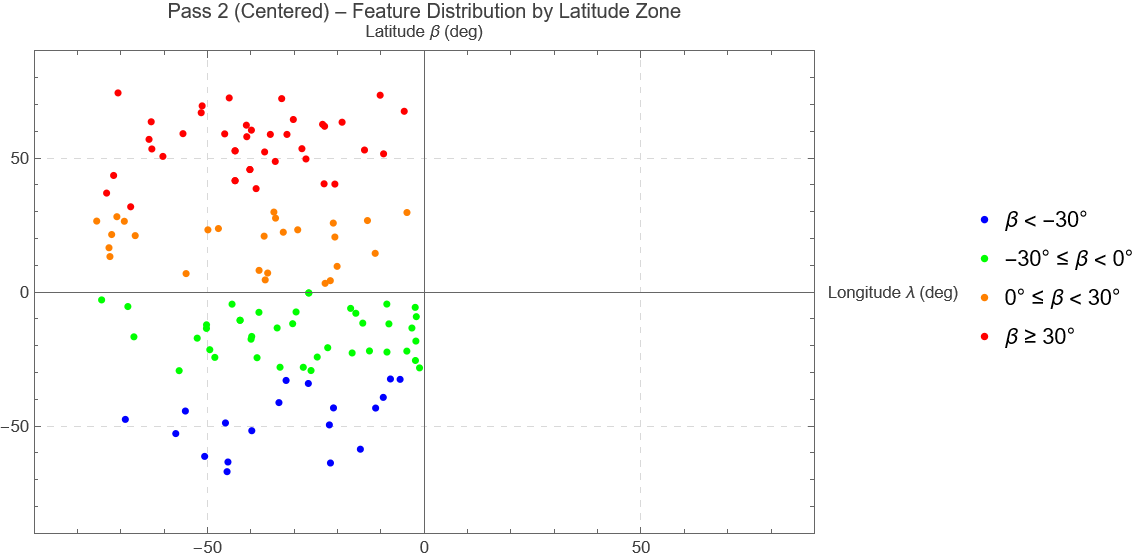

In [451]:
(* (λ,β)-distribution – Pass 2 (Centered) *)
southFeatures = Select[FeatureCoordinatesLongLat, #[[2]] < -30 &];
midSFeatures  = Select[FeatureCoordinatesLongLat, -30 <= #[[2]] < 0 &];
midNFeatures  = Select[FeatureCoordinatesLongLat,   0 <= #[[2]] < 30 &];
northFeatures = Select[FeatureCoordinatesLongLat, #[[2]] >= 30 &];
LambdaBetaPlotPass2 = ListPlot[
  {southFeatures, midSFeatures, midNFeatures, northFeatures},
  PlotRange    -> {{-90, 90}, {-90, 90}},
  PlotStyle    -> {Blue, Green, Orange, Red},
  PlotLegends  -> {"β < −30°", "−30° ≤ β < 0°", "0° ≤ β < 30°", "β ≥ 30°"},
  AxesLabel    -> {"Longitude λ (deg)", "Latitude β (deg)"},
  PlotLabel    -> "Pass 2 (Centered) – Feature Distribution by Latitude Zone",
  GridLines    -> Automatic,
  GridLinesStyle -> Directive[LightGray, Dashed],
  Frame -> True,  ImageSize -> Large
];
LambdaBetaPlotPass2

In [458]:
Export["D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-centered-lambda-beta-dist.pdf", LambdaBetaPlotPass2]
Export["D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-centered-lambda-beta-dist.png", LambdaBetaPlotPass2, ImageResolution -> 300]

D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-centered-lambda-b\
 
>   eta-dist.pdf
D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-centered-lambda-b\
 
>   eta-dist.png

### — Pass2 Selenographic 3D → 2D Cartesian

In [465]:
SelenographicCartesian3D = Table[
  {Cos[FeatureCoordinatesLongLat[[i,2]] Degree] Sin[FeatureCoordinatesLongLat[[i,1]] Degree],
   Sin[FeatureCoordinatesLongLat[[i,2]] Degree],
   Cos[FeatureCoordinatesLongLat[[i,2]] Degree] Cos[FeatureCoordinatesLongLat[[i,1]] Degree]},
  {i, 1, FeatureMax}];
SelenographicCartesian3D[[1]]
SelenographicCartesianxi   = Part[SelenographicCartesian3D[[1 ;; FeatureMax, 1]]];
SelenographicCartesianeta  = Part[SelenographicCartesian3D[[1 ;; FeatureMax, 2]]];
SelenographicCartesianzeta = Part[SelenographicCartesian3D[[1 ;; FeatureMax, 3]]];
SelenographicCartesian2D   = Partition[Riffle[SelenographicCartesianxi, SelenographicCartesianeta], 2];

{-0.338826, 0.16713, 0.925886}

### — Pass2 Lunar disk (ξ, η) plot

-Graphics-
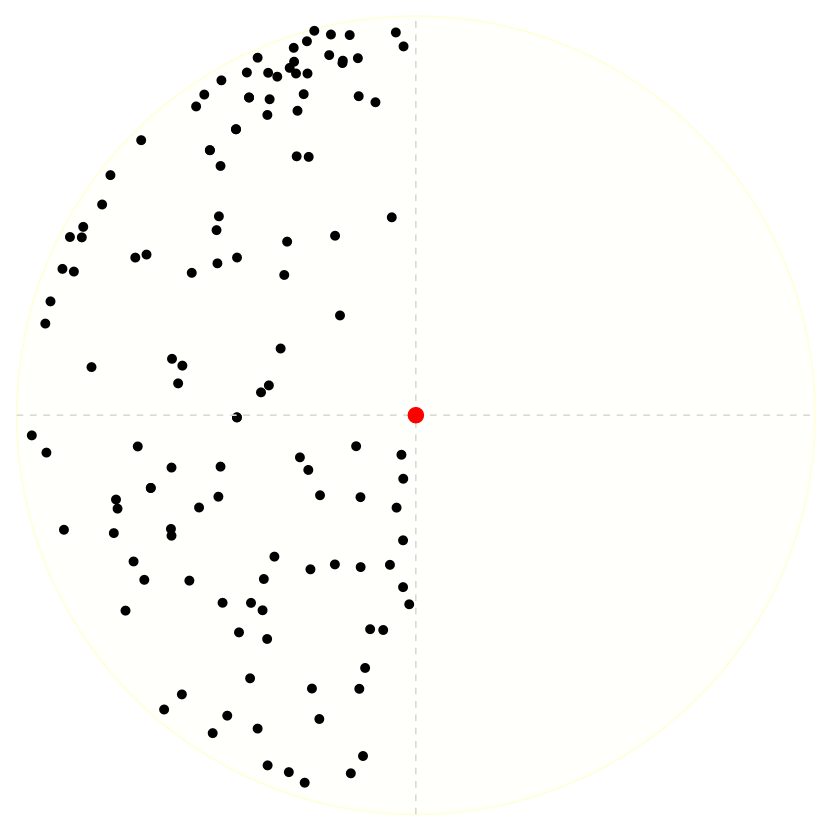

In [475]:
(* 2-D selenographic distribution – Pass 2 (Centered) *)
SelenographicCartesian2DPLOT = ListPlot[
  SelenographicCartesian2D,
  PlotRange -> {{-1.1, 1.1}, {-1.1, 1.1}}, AspectRatio -> 1.0,
  PlotStyle -> Directive[Black, PointSize[0.012]],
  AxesLabel -> {"ξ", "η"},
  PlotLabel -> "Pass 2 (Centered) – Measured Features on Lunar Disk (ξ, η)",
  GridLines -> Automatic, Frame -> True];
LunarDisk    = Graphics[{Opacity[0.08, LightYellow], Disk[{0,0},1], Opacity[1], Circle[{0,0},1]}];
LunarEquator = Graphics[{Dashed, LightGray, Line[{{-1,0},{1,0}}]}];
LunarMerid   = Graphics[{Dashed, LightGray, Line[{{0,-1},{0,1}}]}];
LunarCenter  = Graphics[{Red, PointSize[0.02], Point[{0,0}]}];
DiskPlotPass2 = Show[LunarDisk, SelenographicCartesian2DPLOT,
              LunarEquator, LunarMerid, LunarCenter, ImageSize -> 500];
DiskPlotPass2

In [483]:
Export["D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-centered-xi-eta-disk.pdf", DiskPlotPass2]
Export["D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-centered-xi-eta-disk.png", DiskPlotPass2, ImageResolution -> 300]

D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-centered-xi-eta-d\
 
>   isk.pdf
D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-centered-xi-eta-d\
 
>   isk.png

### — Pass2 Plate calibration (FindFit + NonlinearModelFit)

In [490]:
PlateConstantsDataX = Partition[Flatten[Riffle[SelenographicCartesian3D, PixelCoordinatesX]], 4];
PlateConstantsDataY = Partition[Flatten[Riffle[SelenographicCartesian3D, PixelCoordinatesY]], 4];

BestFitX = FindFit[PlateConstantsDataX, Dpc + Apc xi + Bpc eta + Cpc zeta,
  {Dpc, Apc, Bpc, Cpc}, {xi, eta, zeta}]
BestFitY = FindFit[PlateConstantsDataY, Hpc + Epc xi + Fpc eta + Gpc zeta,
  {Hpc, Epc, Fpc, Gpc}, {xi, eta, zeta}]

-13
{Dpc -> -1.57419 10   , Apc -> 1468.58, Bpc -> 29.2728, Cpc -> 75.6608}
                  -13
{Hpc -> -2.2629 10   , Epc -> -34.9102, Fpc -> 1462.12, Gpc -> -182.671}

Estimate         Standard Error   Confidence Interval

                 -13
Dpc   -1.57419 10      6.39874          {-12.6669, 12.6669}

Apc   1468.58          6.73601          {1455.24, 1481.91}

Bpc   29.2728          2.88809          {23.5555, 34.99}

Cpc   75.6608          7.29009          {61.2293, 90.0922}
      Estimate        Standard Error   Confidence Interval

                -13
Hpc   -2.2629 10      8.53903          {-16.9039, 16.9039}

Epc   -34.9102        8.98912          {-52.7051, -17.1153}

Fpc   1462.12         3.85412          {1454.49, 1469.75}

Gpc   -182.671        9.72853          {-201.93, -163.413}
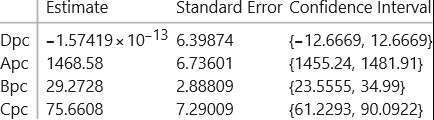
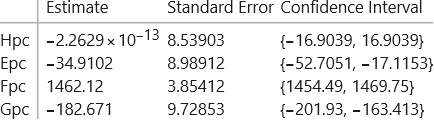

In [494]:
BestFitXnlm = NonlinearModelFit[PlateConstantsDataX,
  Dpc + Apc xi + Bpc eta + Cpc zeta, {Dpc, Apc, Bpc, Cpc}, {xi, eta, zeta}];
BestFitYnlm = NonlinearModelFit[PlateConstantsDataY,
  Hpc + Epc xi + Fpc eta + Gpc zeta, {Hpc, Epc, Fpc, Gpc}, {xi, eta, zeta}];

BestFitXnlm["ParameterConfidenceIntervalTable"]
BestFitYnlm["ParameterConfidenceIntervalTable"]

### — Pass2 Geometric quantities from plate constants

In [502]:
XCenter = BestFitX[[1, 2]]
YCenter = BestFitY[[1, 2]]
RadiusX = Sqrt[(BestFitX[[2,2]])^2 + (BestFitX[[3,2]])^2 + (BestFitX[[4,2]])^2]
RadiusY = Sqrt[(BestFitY[[2,2]])^2 + (BestFitY[[3,2]])^2 + (BestFitY[[4,2]])^2]
AvePixRadius      = (RadiusX + RadiusY) / 2
AvePhysicalRadius = (1736.0 + 1738.1) / 2
AvePixelScale     = AvePhysicalRadius / AvePixRadius
ThetaRotObs = ArcTan[-BestFitX[[3,2]] / BestFitY[[3,2]]] (1/Degree)

-13
-1.57419 10
          -13
-2.2629 10
1470.82
1473.9
1472.36
1737.05
1.17977
-1.14695

### — Pass2 Optical libration angles

In [514]:

AEUnRot = RotationMatrix[-ThetaRotObs Degree].{BestFitX[[2,2]]/RadiusX,
                                               BestFitY[[2,2]]/RadiusY}
AEUnRot[[1]]
ArcCos[AEUnRot[[1]]] (1/Degree)

CGUnRot      = RotationMatrix[-ThetaRotObs Degree].{BestFitX[[4,2]]/RadiusX,
                                                    BestFitY[[4,2]]/RadiusY}
LambdaLibObs = -ArcSin[CGUnRot[[1]]] (1/Degree)
BetaLibObs   =  ArcSin[-CGUnRot[[2]] / Cos[-ArcSin[CGUnRot[[1]]]]] (1/Degree)

{0.998752, -0.00369454}
0.998752
2.86309
{0.0539118, -0.122883}
-3.09042
7.06883

In [521]:
Print["Pass 2 (Centered) — Libration Results"];
Print["  λ_lib,obs = ", N[LambdaLibObs, 7], " deg"];
Print["  β_lib,obs = ", N[BetaLibObs,   7], " deg"];
Print["  θ_rot     = ", N[ThetaRotObs,  7], " deg"];

Pass 2 (Centered) -- Libration Results
  \[Lambda]_lib,obs = -3.09042 deg
  \[Beta]_lib,obs = 7.06883 deg
  \[Theta]_rot     = -1.14695 deg


In [525]:

LambdaLibObsResultPass2 = LambdaLibObs;
BetaLibObsResultPass2   = BetaLibObs;
ThetaRotObsResultPass2  = ThetaRotObs;
RadiusXResultPass2      = RadiusX;
RadiusYResultPass2      = RadiusY;
AvePixScaleResultPass2  = AvePixelScale;
RMSXResultPass2       = Sqrt[Mean[BestFitXnlm["FitResiduals"]^2]];
RMSYResultPass2       = Sqrt[Mean[BestFitYnlm["FitResiduals"]^2]];
Print["Results stored as *ResultPass2"];

Results stored as *ResultPass2



## PASS 3  Parallax-Corrected Coordinates
The corrected file applies the finite-observer distance correction (Appendix 1).  
Compare the libration angles from this pass to the VMA reference values below.

In [539]:
(*third pass: parallax-corrected coordinates.*)
PlateMeasurements = Import["D:/AE-451/Project1/DataFiles/2023-04-13/Measurements/kaoutar-ammara-spring-2026-ae-451-project-1-centered-corr.txt", "Table"];

### — Pass3 Feature count & spot-check

In [545]:
FeatureMax = Length[PlateMeasurements]

126

In [546]:
(* Spot-check: feature 99 *)
PlateMeasurements[[99]]

{Wolf, -325.249, -718.275, -16.633, -22.706}

### — Pass3 Pixel & atlas coordinates

In [552]:
PixelCoordinatesX = Part[PlateMeasurements[[1 ;; FeatureMax, 2]]];
PixelCoordinatesY = Part[PlateMeasurements[[1 ;; FeatureMax, 3]]];
PixelCoordinates  = Partition[Riffle[PixelCoordinatesX, PixelCoordinatesY], 2];
FeatureCoordinatesLong    = Part[PlateMeasurements[[1 ;; FeatureMax, 4]]];
FeatureCoordinatesLat     = Part[PlateMeasurements[[1 ;; FeatureMax, 5]]];
FeatureCoordinatesLongLat = Partition[Riffle[FeatureCoordinatesLong, FeatureCoordinatesLat], 2];

### Pass3 (λ,β) distribution plot

Legended[-Graphics-, Placed[PointLegend[{Directive[PointSize[0.00916667], 
 
>       AbsoluteThickness[2], RGBColor[0, 0, 1]], 
 
>      Directive[PointSize[0.00916667], AbsoluteThickness[2], RGBColor[0, 1, 0]], 
 
>      Directive[PointSize[0.00916667], AbsoluteThickness[2], RGBColor[1, 0.5, 0]], 
 
>      Directive[PointSize[0.00916667], AbsoluteThickness[2], RGBColor[1, 0, 0]]}, 
 
>     {β < −30°, −30° ≤ β < 0°, 0° ≤ β < 30°, β ≥ 30°}, 
 
>     LegendMarkers -> 
 
>      {{False, Automatic}, {False, Automatic}, {False, Automatic}, {False, Automatic}}, 
 
>     Joined -> {False, False, False, False}, LabelStyle -> {}, LegendLayout -> Column], 
 
>    After, Identity]]
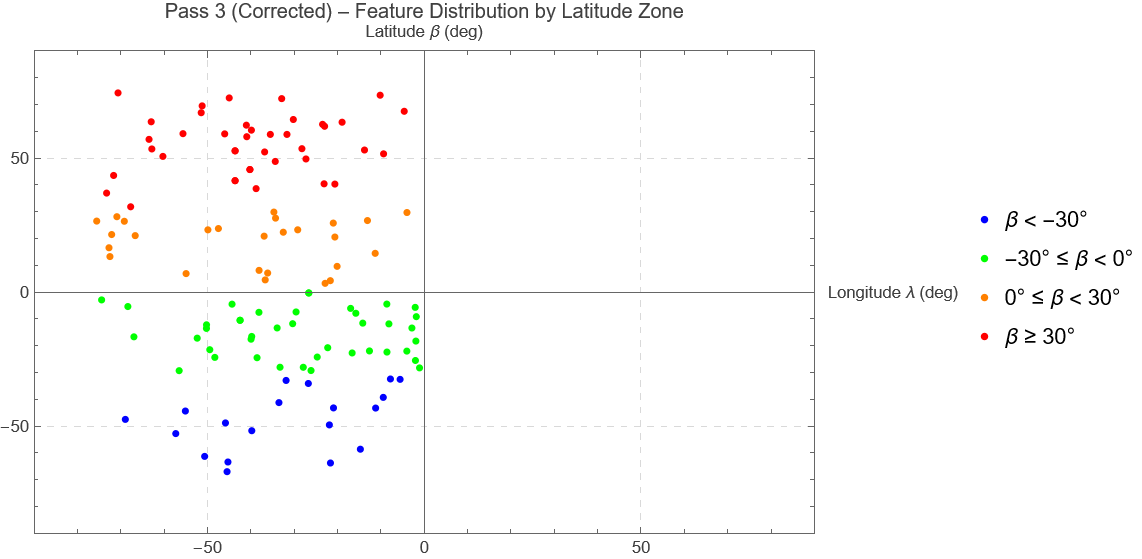

In [562]:
(* (λ,β)-distribution – Pass 3 (Corrected) *)
southFeatures = Select[FeatureCoordinatesLongLat, #[[2]] < -30 &];
midSFeatures  = Select[FeatureCoordinatesLongLat, -30 <= #[[2]] < 0 &];
midNFeatures  = Select[FeatureCoordinatesLongLat,   0 <= #[[2]] < 30 &];
northFeatures = Select[FeatureCoordinatesLongLat, #[[2]] >= 30 &];
LambdaBetaPlotPass3 = ListPlot[
  {southFeatures, midSFeatures, midNFeatures, northFeatures},
  PlotRange    -> {{-90, 90}, {-90, 90}},
  PlotStyle    -> {Blue, Green, Orange, Red},
  PlotLegends  -> {"β < −30°", "−30° ≤ β < 0°", "0° ≤ β < 30°", "β ≥ 30°"},
  AxesLabel    -> {"Longitude λ (deg)", "Latitude β (deg)"},
  PlotLabel    -> "Pass 3 (Corrected) – Feature Distribution by Latitude Zone",
  GridLines    -> Automatic,
  GridLinesStyle -> Directive[LightGray, Dashed],
  Frame -> True,  ImageSize -> Large
];
LambdaBetaPlotPass3

In [569]:
Export["D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-corrected-lambda-beta-dist.pdf", LambdaBetaPlotPass3]
Export["D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-corrected-lambda-beta-dist.png", LambdaBetaPlotPass3, ImageResolution -> 300]

D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-corrected-lambda-\
 
>   beta-dist.pdf
D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-corrected-lambda-\
 
>   beta-dist.png

###  Pass3 Selenographic 3D → 2D Cartesian

In [576]:
SelenographicCartesian3D = Table[
  {Cos[FeatureCoordinatesLongLat[[i,2]] Degree] Sin[FeatureCoordinatesLongLat[[i,1]] Degree],
   Sin[FeatureCoordinatesLongLat[[i,2]] Degree],
   Cos[FeatureCoordinatesLongLat[[i,2]] Degree] Cos[FeatureCoordinatesLongLat[[i,1]] Degree]},
  {i, 1, FeatureMax}];
SelenographicCartesian3D[[1]]
SelenographicCartesianxi   = Part[SelenographicCartesian3D[[1 ;; FeatureMax, 1]]];
SelenographicCartesianeta  = Part[SelenographicCartesian3D[[1 ;; FeatureMax, 2]]];
SelenographicCartesianzeta = Part[SelenographicCartesian3D[[1 ;; FeatureMax, 3]]];
SelenographicCartesian2D   = Partition[Riffle[SelenographicCartesianxi, SelenographicCartesianeta], 2];

{-0.338826, 0.16713, 0.925886}

###  Pass3 Lunar disk (ξ, η) plot

-Graphics-
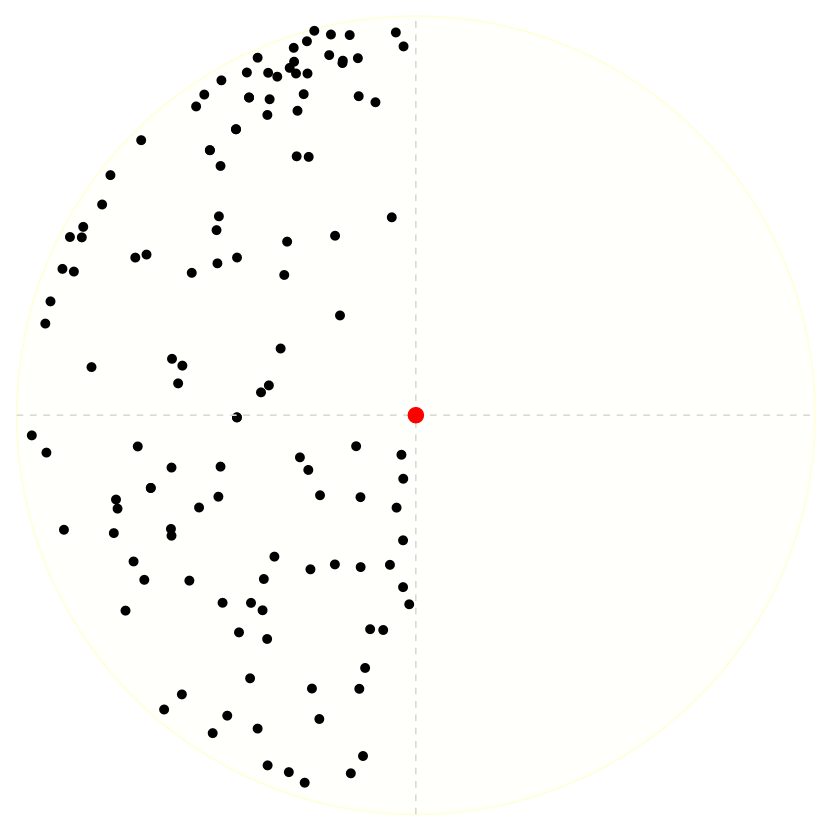

In [586]:
SelenographicCartesian2DPLOT = ListPlot[
  SelenographicCartesian2D,
  PlotRange -> {{-1.1, 1.1}, {-1.1, 1.1}}, AspectRatio -> 1.0,
  PlotStyle -> Directive[Black, PointSize[0.012]],
  AxesLabel -> {"ξ", "η"},
  PlotLabel -> "Pass 3 (Corrected) – Measured Features on Lunar Disk (ξ, η)",
  GridLines -> Automatic, Frame -> True];
LunarDisk    = Graphics[{Opacity[0.08, LightYellow], Disk[{0,0},1], Opacity[1], Circle[{0,0},1]}];
LunarEquator = Graphics[{Dashed, LightGray, Line[{{-1,0},{1,0}}]}];
LunarMerid   = Graphics[{Dashed, LightGray, Line[{{0,-1},{0,1}}]}];
LunarCenter  = Graphics[{Red, PointSize[0.02], Point[{0,0}]}];
DiskPlotPass3 = Show[LunarDisk, SelenographicCartesian2DPLOT,
              LunarEquator, LunarMerid, LunarCenter, ImageSize -> 500];
DiskPlotPass3

In [594]:
Export["D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-corrected-xi-eta-disk.pdf", DiskPlotPass3]
Export["D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-corrected-xi-eta-disk.png", DiskPlotPass3, ImageResolution -> 300]

D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-corrected-xi-eta-\
 
>   disk.pdf
D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-corrected-xi-eta-\
 
>   disk.png

### — Pass3 Plate calibration (FindFit + NonlinearModelFit)

In [601]:
PlateConstantsDataX = Partition[Flatten[Riffle[SelenographicCartesian3D, PixelCoordinatesX]], 4];
PlateConstantsDataY = Partition[Flatten[Riffle[SelenographicCartesian3D, PixelCoordinatesY]], 4];

BestFitX = FindFit[PlateConstantsDataX, Dpc + Apc xi + Bpc eta + Cpc zeta,
  {Dpc, Apc, Bpc, Cpc}, {xi, eta, zeta}]
BestFitY = FindFit[PlateConstantsDataY, Hpc + Epc xi + Fpc eta + Gpc zeta,
  {Hpc, Epc, Fpc, Gpc}, {xi, eta, zeta}]

{Dpc -> -1.45501, Apc -> 1464.48, Bpc -> 29.5276, Cpc -> 77.756}
{Hpc -> -0.0655413, Epc -> -34.6099, Fpc -> 1458.63, Gpc -> -181.767}

Estimate   Standard Error   Confidence Interval

Dpc   -1.45501   6.35922          {-14.0437, 11.1337}

Apc   1464.48    6.69441          {1451.23, 1477.74}

Bpc   29.5276    2.87025          {23.8456, 35.2095}

Cpc   77.756     7.24506          {63.4137, 92.0983}
      Estimate     Standard Error   Confidence Interval

Hpc   -0.0655413   8.52164          {-16.935, 16.8039}

Epc   -34.6099     8.97081          {-52.3685, -16.8512}

Fpc   1458.63      3.84626          {1451.02, 1466.24}

Gpc   -181.767     9.70871          {-200.986, -162.548}
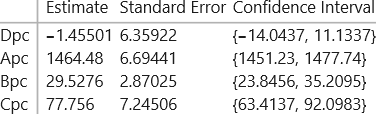
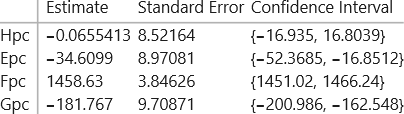

In [605]:
BestFitXnlm = NonlinearModelFit[PlateConstantsDataX,
  Dpc + Apc xi + Bpc eta + Cpc zeta, {Dpc, Apc, Bpc, Cpc}, {xi, eta, zeta}];
BestFitYnlm = NonlinearModelFit[PlateConstantsDataY,
  Hpc + Epc xi + Fpc eta + Gpc zeta, {Hpc, Epc, Fpc, Gpc}, {xi, eta, zeta}];

BestFitXnlm["ParameterConfidenceIntervalTable"]
BestFitYnlm["ParameterConfidenceIntervalTable"]

### — Pass3 Geometric quantities from plate constants

In [613]:
XCenter = BestFitX[[1, 2]]
YCenter = BestFitY[[1, 2]]
RadiusX = Sqrt[(BestFitX[[2,2]])^2 + (BestFitX[[3,2]])^2 + (BestFitX[[4,2]])^2]
RadiusY = Sqrt[(BestFitY[[2,2]])^2 + (BestFitY[[3,2]])^2 + (BestFitY[[4,2]])^2]
AvePixRadius      = (RadiusX + RadiusY) / 2
AvePhysicalRadius = (1736.0 + 1738.1) / 2
AvePixelScale     = AvePhysicalRadius / AvePixRadius
ThetaRotObs = ArcTan[-BestFitX[[3,2]] / BestFitY[[3,2]]] (1/Degree)

-1.45501
-0.0655413
1466.84
1470.32
1468.58
1737.05
1.18281
-1.1597

### — Pass3 Optical libration angles

In [625]:
AEUnRot = RotationMatrix[-ThetaRotObs Degree].{BestFitX[[2,2]]/RadiusX,
                                               BestFitY[[2,2]]/RadiusY}
AEUnRot[[1]]
ArcCos[AEUnRot[[1]]] (1/Degree)

CGUnRot      = RotationMatrix[-ThetaRotObs Degree].{BestFitX[[4,2]]/RadiusX,
                                                    BestFitY[[4,2]]/RadiusY}
LambdaLibObs = -ArcSin[CGUnRot[[1]]] (1/Degree)
BetaLibObs   =  ArcSin[-CGUnRot[[2]] / Cos[-ArcSin[CGUnRot[[1]]]]] (1/Degree)

{0.998663, -0.00332754}
0.998663
2.96311
{0.0555002, -0.122526}
-3.18156
7.04883

In [632]:
Print["Pass 3 (Corrected) — Libration Results"];
Print["  λ_lib,obs = ", N[LambdaLibObs, 7], " deg"];
Print["  β_lib,obs = ", N[BetaLibObs,   7], " deg"];
Print["  θ_rot     = ", N[ThetaRotObs,  7], " deg"];

Pass 3 (Corrected) -- Libration Results
  \[Lambda]_lib,obs = -3.18156 deg
  \[Beta]_lib,obs = 7.04883 deg
  \[Theta]_rot     = -1.1597 deg


In [636]:
(* Preserve Pass 3 (Corrected) results under unique variable names *)
LambdaLibObsResultPass3 = LambdaLibObs;
BetaLibObsResultPass3   = BetaLibObs;
ThetaRotObsResultPass3  = ThetaRotObs;
RadiusXResultPass3      = RadiusX;
RadiusYResultPass3      = RadiusY;
AvePixScaleResultPass3  = AvePixelScale;
RMSXResultPass3       = Sqrt[Mean[BestFitXnlm["FitResiduals"]^2]];
RMSYResultPass3       = Sqrt[Mean[BestFitYnlm["FitResiduals"]^2]];
Print["Results stored as *ResultPass3"];

Results stored as *ResultPass3



## Three-Pass Comparison Table
Comparing libration results across the three processing stages alongside the VMA reference.

In [650]:
(* Three-pass comparison; runs after all three passes are complete *)
Print["============================================================"];
Print["          THREE-PASS LIBRATION COMPARISON"];
Print["============================================================"];
Print[StringForm["  `1`  λ = `2` deg   β = `3` deg",
  "Pass 1 (Raw)      : ", N[LambdaLibObsResultRaw, 6],   N[BetaLibObsResultRaw, 6]]];
Print[StringForm["  `1`  λ = `2` deg   β = `3` deg",
  "Pass 2 (Centered) : ", N[LambdaLibObsResultPass2, 6], N[BetaLibObsResultPass2, 6]]];
Print[StringForm["  `1`  λ = `2` deg   β = `3` deg",
  "Pass 3 (Corrected): ", N[LambdaLibObsResultPass3, 6], N[BetaLibObsResultPass3, 6]]];
Print[StringForm["  `1`  λ = `2` deg   β = `3` deg",
  "VMA Reference     : ", N[LambdaLibVMA, 6],            N[BetaLibVMA, 6]]];
Print["------------------------------------------------------------"];
Print[StringForm["  Δλ (Pass3 − VMA) = `1` deg   Δβ (Pass3 − VMA) = `2` deg",
  N[LambdaLibObsResultPass3 - LambdaLibVMA, 4],
  N[BetaLibObsResultPass3   - BetaLibVMA,   4]]];

          THREE-PASS LIBRATION COMPARISON
  Pass 1 (Raw)      :   \[Lambda] = -3.09042 deg   \[Beta] = 7.06883 deg
  Pass 2 (Centered) :   \[Lambda] = -3.09042 deg   \[Beta] = 7.06883 deg
  Pass 3 (Corrected):   \[Lambda] = -3.18156 deg   \[Beta] = 7.04883 deg
  VMA Reference     :   \[Lambda] = -2.70000 deg   \[Beta] = 7.50000 deg
------------------------------------------------------------
  \[CapitalDelta]\[Lambda] (Pass3 - VMA) = -0.481562
 
>    deg   \[CapitalDelta]\[Beta] (Pass3 - VMA) = -0.451174 deg


## Final Comparison: Measured vs VMA Libration

Once the plate solution is complete, the cell below prints your
photogrammetrically determined libration angles and compares them
to the reference values from VMA.

In [668]:
(* Compare plate-solution libration to VMA reference *)
Print["=== LIBRATION COMPARISON ==="];
Print["Libration in longitude:"];
Print["  Plate solution : ", N[LambdaLibObs], " deg"];
Print["  VMA reference  : ", N[LambdaLibVMA], " deg"];
Print["  Difference     : ", N[LambdaLibObs - LambdaLibVMA], " deg"];
Print[];
Print["Libration in latitude:"];
Print["  Plate solution : ", N[BetaLibObs],   " deg"];
Print["  VMA reference  : ", N[BetaLibVMA],   " deg"];
Print["  Difference     : ", N[BetaLibObs - BetaLibVMA], " deg"];
Print[];
Print["Position angle:"];
Print["  Plate solution : ", N[ThetaRotObs],   " deg"];
Print["  VMA reference  : ", PositionAngleVMA, " deg"];
Print["  Difference     : ", N[ThetaRotObs - PositionAngleVMA], " deg"];

=== LIBRATION COMPARISON ===
Libration in longitude:
  Plate solution : -3.18156 deg
  VMA reference  : -2.7 deg
  Difference     : -0.481562 deg

Libration in latitude:
  Plate solution : 7.04883 deg
  VMA reference  : 7.5 deg
  Difference     : -0.451174 deg

Position angle:
  Plate solution : -1.1597 deg
  VMA reference  : -9.1 deg
  Difference     : 7.9403 deg


## Plate Calibration Residual Analysis

A good plate solution requires that the fit residuals are small and randomly distributed.
The cells below plot the residuals for both the $X$- and $Y$-fits and compute their
root-mean-square (RMS) value in pixels, which quantifies the goodness of the plate calibration.

RMS residual X-fit : 16.4111 px  (19.4111 km)
RMS residual Y-fit : 21.9916 px  (26.0118 km)


-Graphics-
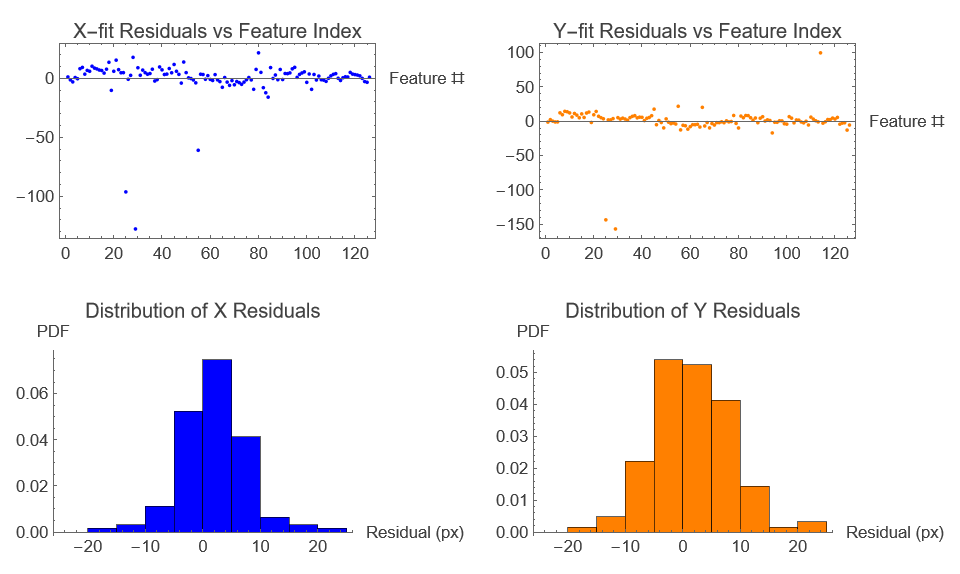

In [706]:
ResidualsX = BestFitXnlm["FitResiduals"];
ResidualsY = BestFitYnlm["FitResiduals"];
RMSX = Sqrt[Mean[ResidualsX^2]];
RMSY = Sqrt[Mean[ResidualsY^2]];
Print["RMS residual X-fit : ", RMSX, " px  (", RMSX * AvePixelScale, " km)"];
Print["RMS residual Y-fit : ", RMSY, " px  (", RMSY * AvePixelScale, " km)"];

featureIndices = Range[FeatureMax];
pResX = ListPlot[Transpose[{featureIndices, ResidualsX}],
  PlotStyle -> Directive[Blue, PointSize[0.012]], PlotLabel -> "X-fit Residuals vs Feature Index",
  AxesLabel -> {"Feature #", "Residual (px)"}, PlotRange -> All, Frame -> True,
  GridLines -> {None, {0}}, GridLinesStyle -> {Red, Dashed}];
pResY = ListPlot[Transpose[{featureIndices, ResidualsY}],
  PlotStyle -> Directive[Orange, PointSize[0.012]], PlotLabel -> "Y-fit Residuals vs Feature Index",
  AxesLabel -> {"Feature #", "Residual (px)"}, PlotRange -> All, Frame -> True,
  GridLines -> {None, {0}}, GridLinesStyle -> {Red, Dashed}];
hResX = Histogram[ResidualsX, Automatic, "PDF",
  PlotLabel -> "Distribution of X Residuals", AxesLabel -> {"Residual (px)", "PDF"}, ChartStyle -> Blue];
hResY = Histogram[ResidualsY, Automatic, "PDF",
  PlotLabel -> "Distribution of Y Residuals", AxesLabel -> {"Residual (px)", "PDF"}, ChartStyle -> Orange];
BonusBResidualGrid = GraphicsGrid[{{pResX, pResY}, {hResX, hResY}}, ImageSize -> Large];
BonusBResidualGrid

In [720]:
Export["D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-residual-analysis.pdf", BonusBResidualGrid]
Export["D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-residual-analysis.png", BonusBResidualGrid]

D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-residual-analysis\
 
>   .pdf
D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-residual-analysis\
 
>   .png

## Selenographic Coordinate Recovery Check

To assess the quality of the plate solution, we can *recover* the selenographic
coordinates of each feature from the fitted plate constants and compare them to the
catalog values taken from the Virtual Moon Atlas. The residuals in angular
coordinates provide an independent quality metric.

Mean |\[CapitalDelta]\[Lambda]| = 4.93315 deg
Mean |\[CapitalDelta]\[Beta]| = 4.73661 deg
Max  |\[CapitalDelta]\[Lambda]| = 18.3295 deg  (feature #10)
Max  |\[CapitalDelta]\[Beta]| = 15.2991 deg  (feature #25)


Legended[-Graphics-, Placed[PointLegend[{Directive[PointSize[0.00733333], 
 
>       AbsoluteThickness[2], Dashing[{Small, Small}], GrayLevel[0.5]], 
 
>      Directive[AbsoluteThickness[2], RGBColor[0, 0, 1], PointSize[0.01]]}, 
 
>     {1:1 line, Recovered}, LegendMarkers -> {{False, Automatic}, {False, Automatic}}, 
 
>     Joined -> {False, False}, LabelStyle -> {}, LegendLayout -> Column], After, 
 
>    Identity]]
Legended[-Graphics-, Placed[PointLegend[{Directive[PointSize[0.00733333], 
 
>       AbsoluteThickness[2], Dashing[{Small, Small}], GrayLevel[0.5]], 
 
>      Directive[AbsoluteThickness[2], RGBColor[1, 0.5, 0], PointSize[0.01]]}, 
 
>     {1:1 line, Recovered}, LegendMarkers -> {{False, Automatic}, {False, Automatic}}, 
 
>     Joined -> {False, False}, LabelStyle -> {}, LegendLayout -> Column], After, 
 
>    Identity]]
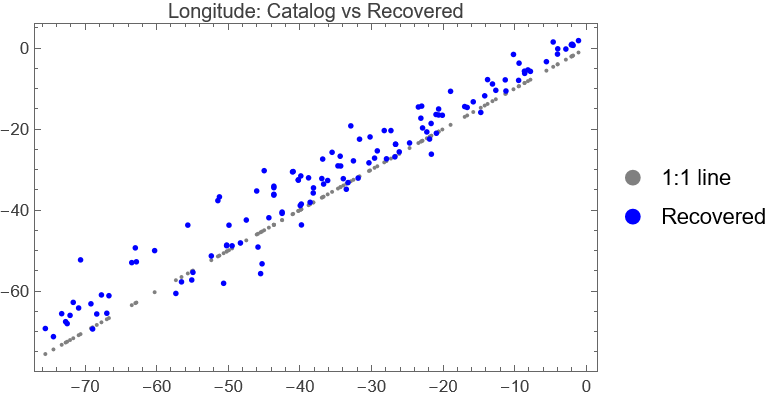
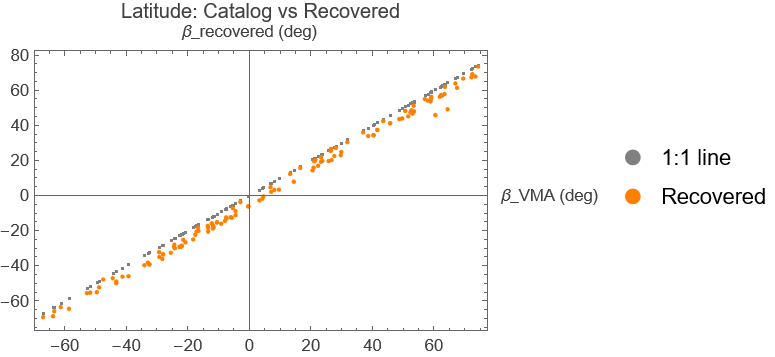

In [727]:
(* Recover (λ, β) from fitted plate constants for each feature *)
Apc = BestFitX[[2, 2]]; Bpc = BestFitX[[3, 2]]; Cpc = BestFitX[[4, 2]]; Dpc = BestFitX[[1, 2]];
Epc = BestFitY[[2, 2]]; Fpc = BestFitY[[3, 2]]; Gpc = BestFitY[[4, 2]]; Hpc = BestFitY[[1, 2]];

RecoveredXi  = Table[(PixelCoordinatesX[[i]] - Dpc) / RadiusX, {i, 1, FeatureMax}];
RecoveredEta = Table[(PixelCoordinatesY[[i]] - Hpc) / RadiusY, {i, 1, FeatureMax}];

RecoveredLambda = Table[
   ArcSin[RecoveredXi[[i]] /
      Sqrt[1 - RecoveredEta[[i]]^2]] (1/Degree), {i, 1, FeatureMax}];
RecoveredBeta = Table[
   ArcSin[RecoveredEta[[i]]] (1/Degree), {i, 1, FeatureMax}];

DeltaLambda = RecoveredLambda - FeatureCoordinatesLong;
DeltaBeta   = RecoveredBeta   - FeatureCoordinatesLat;

Print["Mean |Δλ| = ", Mean[Abs[DeltaLambda]], " deg"];
Print["Mean |Δβ| = ", Mean[Abs[DeltaBeta]],   " deg"];
Print["Max  |Δλ| = ", Max[Abs[DeltaLambda]],  " deg  (feature #",
      Position[Abs[DeltaLambda], Max[Abs[DeltaLambda]]][[1,1]], ")"];
Print["Max  |Δβ| = ", Max[Abs[DeltaBeta]],    " deg  (feature #",
      Position[Abs[DeltaBeta],   Max[Abs[DeltaBeta]]][[1,1]],   ")"];

(* Scatter: VMA coords vs. recovered coords *)
pLambda = ListPlot[
   {Transpose[{FeatureCoordinatesLong, FeatureCoordinatesLong}],
    Transpose[{FeatureCoordinatesLong, RecoveredLambda}]},
   PlotStyle -> {{Dashed, Gray}, {Blue, PointSize[0.01]}},
   PlotLabel -> "Longitude: Catalog vs Recovered",
   AxesLabel -> {"λ_VMA (deg)", "λ_recovered (deg)"},
   PlotLegends -> {"1:1 line", "Recovered"},
   Frame -> True]

pBeta = ListPlot[
   {Transpose[{FeatureCoordinatesLat, FeatureCoordinatesLat}],
    Transpose[{FeatureCoordinatesLat, RecoveredBeta}]},
   PlotStyle -> {{Dashed, Gray}, {Orange, PointSize[0.01]}},
   PlotLabel -> "Latitude: Catalog vs Recovered",
   AxesLabel -> {"β_VMA (deg)", "β_recovered (deg)"},
   PlotLegends -> {"1:1 line", "Recovered"},
   Frame -> True]


## Summary Table of Results

A concise summary of all key numerical results from the project, formatted for
easy inclusion in your report.

Quantity                       Value        Unit

Number of features used        126          –

Moon distance (FITS header)    368567       km

Mean physical radius (used)    1737.05      km

Angular radius of Moon         0.270035     deg

Pixel radius (X-axis)          1466.84      px

Pixel radius (Y-axis)          1470.32      px

Average pixel scale            1.18281      km/px

Center of Moon X_C             -1.45501     px

Center of Moon Y_C             -0.0655413   px

Polar-axis rotation θ          -1.1597      deg

Libration in longitude λ_obs   -3.18156     deg

Libration in latitude β_obs    7.04883      deg

RMS residual (X-fit)           16.4111      px

RMS residual (Y-fit)           21.9916      px
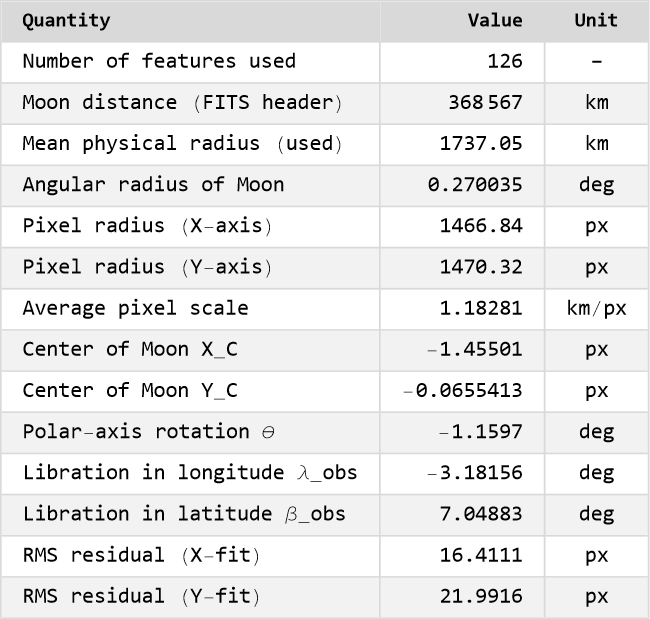

In [773]:
Grid[{
   {Style["Quantity", Bold, 12], Style["Value", Bold, 12], Style["Unit", Bold, 12]},
   {"Number of features used",        FeatureMax,                        "–"},
   {"Moon distance (FITS header)",     rMoon/10^3,                       "km"},
   {"Mean physical radius (used)",     AvePhysicalRadius,                "km"},
   {"Angular radius of Moon",
        N[AveAngularRadiusDeg],                                           "deg"},
   {"Pixel radius (X-axis)",           N[RadiusX],                       "px"},
   {"Pixel radius (Y-axis)",           N[RadiusY],                       "px"},
   {"Average pixel scale",             N[AvePixelScale],                 "km/px"},
   {"Center of Moon X_C",              N[XCenter],                       "px"},
   {"Center of Moon Y_C",              N[YCenter],                       "px"},
   {"Polar-axis rotation θ",           N[ThetaRotObs],                   "deg"},
   {"Libration in longitude λ_obs",    N[LambdaLibObs],                  "deg"},
   {"Libration in latitude β_obs",     N[BetaLibObs],                    "deg"},
   {"RMS residual (X-fit)",            N[RMSX],                         "px"},
   {"RMS residual (Y-fit)",            N[RMSY],                         "px"}
},
   Frame -> All,
   FrameStyle -> LightGray,
   Alignment -> {{Left, Right, Center}},
   Background -> {{}, {GrayLevel[0.85], {White, GrayLevel[0.95]}}},
   Spacings -> {2, 1}]

In [1104]:
(* First capture the table as a graphic, then export *)
SummaryTableGraphic = Rasterize[
  Grid[{
    {Style["Quantity", Bold, 12], Style["Value", Bold, 12], Style["Unit", Bold, 12]},
    {"Number of features used",       FeatureMax,                 "–"},
    {"Moon distance (FITS header)",    rMoon/10^3,                "km"},
    {"Mean physical radius (used)",    AvePhysicalRadius,         "km"},
    {"Angular radius of Moon",         N[AveAngularRadiusDeg],    "deg"},
    {"Pixel radius (X-axis)",          N[RadiusX],                "px"},
    {"Pixel radius (Y-axis)",          N[RadiusY],                "px"},
    {"Average pixel scale",            N[AvePixelScale],          "km/px"},
    {"Center of Moon X_C",             N[XCenter],                "px"},
    {"Center of Moon Y_C",             N[YCenter],                "px"},
    {"Polar-axis rotation θ",          N[ThetaRotObs],            "deg"},
    {"λ_obs (Pass 3 / Corrected)",     N[LambdaLibObs],           "deg"},
    {"β_obs (Pass 3 / Corrected)",     N[BetaLibObs],             "deg"},
    {"λ_VMA reference",                N[LambdaLibVMA],           "deg"},
    {"β_VMA reference",                N[BetaLibVMA],             "deg"},
    {"RMS residual X-fit",             N[RMSX],                  "px"},
    {"RMS residual Y-fit",             N[RMSY],                  "px"}
  },
  Frame -> All, FrameStyle -> LightGray,
  Alignment -> {{Left, Right, Center}},
  Background -> {{}  , {GrayLevel[0.85], {White, GrayLevel[0.95]}}},
  Spacings -> {2, 1}
], ImageResolution -> 300];
Export["D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-summary-table.pdf", SummaryTableGraphic]
Export["D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-summary-table.png", SummaryTableGraphic]

D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-summary-table.pdf
D:/AE-451/Project1/Figures/kaoutar-ammara-spring-2026-ae-451-project-1-summary-table.png

<div class="alert alert-block alert-info">
<span style='color:black'>  "Introduction to lunar photogrammetry and optical libration determination" by Fabrizio Pinto is licensed under a Creative Commons Attribution 4.0 International License, except where otherwise noted.</span> <br> 
    
https://creativecommons.org/licenses/by/4.0/   </div> 

 <div class="alert alert-block alert-info"> <span style='color:black'>
${\mathbf{Attribution}}$ — You must give appropriate credit, provide a link to the license, and indicate if changes were made. You may do so in any reasonable manner, but not in any way that suggests the licensor endorses you or your use. </div> 